# Pregunta Analítica 3 — Pricing del Seguro Indexado

**Pipeline:**  IC definitivo (IC_WI_ext) → STL (diagnóstico) → Selección de variable de pricing → PAYOUT_MAX calibrado → Plan A: OLS calibrado | Plan B: Lineal original → Comparación → Exportación

---
## Tabla de contenidos
1. Configuración y carga de datos
2. STL y selección de variable de pricing
3. PAYOUT_MAX calibrado (compartido entre planes)
4. Plan A — Curva de pago calibrada (OLS)
   - 4a. Ajuste OLS: Pérdida ~ IC en zona de disparo
   - 4b. Distribución Weibull por celda
   - 4c. Monte Carlo con curva calibrada
   - 4d. Prima pura + R1/R2/R3
5. Plan B — Curva de pago lineal (original)
   - 5a. Monte Carlo con curva lineal p10→p5
   - 5b. Prima pura + R1/R2/R3
6. Comparación de planes
7. Diagnósticos HE
8. Exportación


## 1. Configuración y carga de datos

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib, os, warnings
from statsmodels.tsa.seasonal import STL
from scipy import stats
from scipy.stats import gamma as gamma_dist
from scipy.stats import anderson

warnings.filterwarnings('ignore')
np.random.seed(42)   # semilla fija — reproducibilidad R3

INPUT_DIR  = '../output_ic'
OUTPUT_DIR = '../output_pa3'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Cargar parquets con IC ya calculado
df_train = pd.read_parquet(f'{INPUT_DIR}/df_train_ic.parquet')
df_val   = pd.read_parquet(f'{INPUT_DIR}/df_val_ic.parquet')
df_test  = pd.read_parquet(f'{INPUT_DIR}/df_test_ic.parquet')

# IC definitivo seleccionado en PA2
COL_IC = 'IC_WI_ext'

# Verificar que la columna existe
for nombre, df in [('TRAIN', df_train), ('VAL', df_val), ('TEST', df_test)]:
    assert COL_IC in df.columns, f'{COL_IC} no encontrado en {nombre}'
    ic = df[COL_IC].dropna()
    print(f'{nombre}: {len(df):,} filas | IC válido: {len(ic):,} | '
          f'media={ic.mean():.3f} | std={ic.std():.3f} | '
          f'rango=[{ic.min():.2f}, {ic.max():.2f}]')

# Usar 'IC' como nombre estándar
for df in [df_train, df_val, df_test]:
    df['IC'] = df[COL_IC]

print(f'\nIC definitivo: {COL_IC}')
print('Construido sobre: Z-scores de variables climáticas, pesos calibrados')
print('sobre observaciones de estrés (NDVI_anom < p20 en train)')

TRAIN: 17,934 filas | IC válido: 17,934 | media=-0.000 | std=0.561 | rango=[-1.78, 1.83]
VAL: 3,332 filas | IC válido: 3,332 | media=-0.033 | std=0.575 | rango=[-1.66, 2.32]
TEST: 4,802 filas | IC válido: 4,802 | media=-0.063 | std=0.584 | rango=[-2.27, 1.59]

IC definitivo: IC_WI_ext
Construido sobre: Z-scores de variables climáticas, pesos calibrados
sobre observaciones de estrés (NDVI_anom < p20 en train)


## 2. STL y selección de variable de pricing

Se descompone el IC en Tendencia (T), Estacionalidad (S) y Residuo (R) mediante STL para evaluar cuál componente —o el IC completo— mantiene la mayor correlación con NDVI_anom.

**Hipótesis teórica:**
- IC completo: correlación moderada (no elimina nada)
- T (tendencia): correlación baja — NDVI_anom ya está detrended por período
- S (estacionalidad): correlación casi nula — NDVI_anom es Z-score por DOY
- R (residuo): correlación esperada más alta — ambos capturan shocks anómalos

Se selecciona automáticamente la variable con mayor correlación Spearman con NDVI_anom en el set de test.

In [3]:
# =====================================================================
# 2a. STL sobre TRAIN → aplicar parámetros a VAL y TEST
#
# Metodología correcta (sin data leakage):
#   1. Ajustar STL pixel a pixel sobre la serie de TRAIN
#   2. Extraer S por período (promedio estacional por slot 0-22)
#   3. Extraer T_final (promedio de tendencia del último año de train)
#      como estimación del nivel de tendencia post-train
#   4. Calcular R para VAL y TEST: R = IC - T_final - S(período)
#
# T_final es constante para val y test por píxel — es una aproximación
# aceptable para el MVP. Se documenta como limitación.
# =====================================================================

PERIOD_STL = 23   # ~1 año en períodos de 16 días
UMBRAL_T   = 0.15
UMBRAL_S   = 0.10

def periodo_en_año(fecha):
    inicio = fecha.apply(lambda d: d.replace(month=1, day=1))
    return ((fecha - inicio).dt.days // 16).astype(int)

# Inicializar columnas STL en los tres splits
for df in [df_train, df_val, df_test]:
    df[['T_IC', 'S_IC', 'R_IC']] = np.nan
    df['periodo'] = periodo_en_año(df['fecha'])

n_ok, n_skip = 0, 0

for (lat, lon), grupo_train in df_train.groupby(['lat', 'lon']):
    serie = grupo_train.sort_values('fecha')['IC'].reset_index(drop=True)

    if serie.isna().any() or len(serie) < 2 * PERIOD_STL:
        n_skip += 1
        continue

    try:
        res = STL(serie, period=PERIOD_STL, robust=True).fit()
    except Exception:
        n_skip += 1
        continue

    # ── 1. Asignar T, S, R en TRAIN ──────────────────────────────────
    idx_train = grupo_train.sort_values('fecha').index
    df_train.loc[idx_train, 'T_IC'] = res.trend.values
    df_train.loc[idx_train, 'S_IC'] = res.seasonal.values
    df_train.loc[idx_train, 'R_IC'] = res.resid.values

    # ── 2. Estacionalidad por período (promedio de S en train) ────────
    periodos_train = grupo_train.sort_values('fecha')['periodo'].values
    s_por_periodo  = (
        pd.Series(res.seasonal.values, index=periodos_train)
        .groupby(level=0).mean()
    )

    # ── 3. Tendencia final: promedio último año de train ──────────────
    t_final = res.trend.values[-PERIOD_STL:].mean()

    # ── 4. Aplicar a VAL y TEST ───────────────────────────────────────
    for df_split in [df_val, df_test]:
        mask = (df_split['lat'] == lat) & (df_split['lon'] == lon)
        if mask.sum() == 0:
            continue
        sub   = df_split.loc[mask]
        S_rep = sub['periodo'].map(s_por_periodo).fillna(0).values
        df_split.loc[mask, 'T_IC'] = t_final
        df_split.loc[mask, 'S_IC'] = S_rep
        df_split.loc[mask, 'R_IC'] = sub['IC'].values - t_final - S_rep

    n_ok += 1

print(f'STL aplicado: {n_ok} píxeles OK | {n_skip} omitidos')


STL aplicado: 49 píxeles OK | 0 omitidos


=== CORRELACIÓN DE COMPONENTES STL CON NDVI_anom (TEST) ===
Variable           Pearson   Spearman    N obs
────────────────────────────────────────────────
  IC             :    +0.5126    +0.3933    2,097
  T_IC           :    +0.5183    +0.3791    2,097
  S_IC           :    -0.0075    -0.0051    2,097
  R_IC           :    +0.0769    +0.0940    2,097

→ Variable con mayor correlación Spearman: IC (ρ=0.3933)


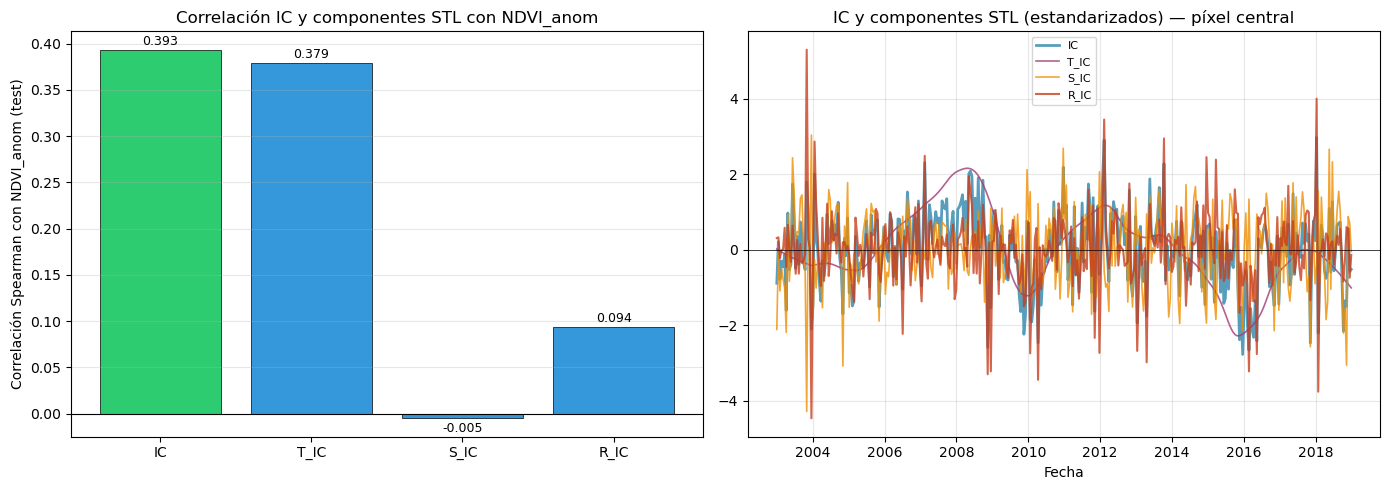

In [4]:
# =====================================================================
# 2b. Correlación de IC, T_IC, S_IC, R_IC con NDVI_anom
#
# Se evalúa en TEST (no en TRAIN para evitar sobreajuste informativo).
# La variable con mayor ρ de Spearman será COL_PRICING.
#
# T y S se incluyen aunque la expectativa teórica sea correlación baja:
# la evidencia empírica documenta por qué se descarta la descomposición STL.
# =====================================================================

print('=== CORRELACIÓN DE COMPONENTES STL CON NDVI_anom (TEST) ===')
print(f'{"Variable":<15} {"Pearson":>10} {"Spearman":>10} {"N obs":>8}')
print('─' * 48)

corrs = {}
for col in ['IC', 'T_IC', 'S_IC', 'R_IC']:
    if col not in df_test.columns:
        print(f'  {col:<15}: no disponible')
        continue
    sub = df_test[[col, 'NDVI_anom']].dropna()
    if len(sub) < 30:
        print(f'  {col:<15}: insuficientes datos (n={len(sub)})')
        continue
    r,   _ = stats.pearsonr(sub[col],  sub['NDVI_anom'])
    rho, _ = stats.spearmanr(sub[col], sub['NDVI_anom'])
    corrs[col] = rho
    print(f'  {col:<15}: {r:>+10.4f} {rho:>+10.4f} {len(sub):>8,}')

# Decisión automática: variable con mayor Spearman
mejor_col = max(corrs, key=corrs.get) if corrs else 'IC'
print(f'\n→ Variable con mayor correlación Spearman: {mejor_col} (ρ={corrs.get(mejor_col, 0):.4f})')

# Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izq: correlaciones en barras
ax = axes[0]
cols_plot = [c for c in ['IC', 'T_IC', 'S_IC', 'R_IC'] if c in corrs]
vals_plot  = [corrs[c] for c in cols_plot]
colores    = ['#2ECC71' if c == mejor_col else '#3498DB' for c in cols_plot]
ax.bar(cols_plot, vals_plot, color=colores, edgecolor='black', linewidth=0.5)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Correlación Spearman con NDVI_anom (test)')
ax.set_title('Correlación IC y componentes STL con NDVI_anom')
ax.grid(True, alpha=0.3, axis='y')
for i, (c, v) in enumerate(zip(cols_plot, vals_plot)):
    ax.text(i, v + 0.005 if v >= 0 else v - 0.015,
            f'{v:.3f}', ha='center', fontsize=9)

# Panel der: pixel representativo — IC vs componentes
ax = axes[1]
pixel_ref = df_train[
    (df_train['lat'] == df_train['lat'].unique()[len(df_train['lat'].unique())//2]) &
    (df_train['lon'] == df_train['lon'].unique()[len(df_train['lon'].unique())//2])
].sort_values('fecha')
for col, color, lw in [('IC','#2E86AB',2),('T_IC','#A23B72',1.2),
                        ('S_IC','#F18F01',1.2),('R_IC','#C73E1D',1.5)]:
    if col in pixel_ref.columns and pixel_ref[col].notna().sum() > 5:
        serie = pixel_ref[col]
        serie_norm = (serie - serie.mean()) / serie.std()
        ax.plot(pixel_ref['fecha'], serie_norm,
                color=color, linewidth=lw, label=col, alpha=0.8)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_title('IC y componentes STL (estandarizados) — píxel central')
ax.set_xlabel('Fecha')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [5]:
# =====================================================================
# 2c. Decisión de COL_PRICING y justificación
# =====================================================================

COL_PRICING = mejor_col
USAR_RESIDUO = (COL_PRICING == 'R_IC')

print(f'=== DECISIÓN: COL_PRICING = {COL_PRICING} ===')
print(f'\nCorrelaciones Spearman con NDVI_anom:')
for col, rho in sorted(corrs.items(), key=lambda x: x[1], reverse=True):
    marca = ' ← SELECCIONADO' if col == COL_PRICING else ''
    print(f'  {col:<10}: ρ = {rho:+.4f}{marca}')

print(f'\nJustificación:')
if COL_PRICING == 'IC':
    print(f'  El IC completo mantiene la mayor correlación con NDVI_anom.')
    print(f'  La descomposición STL no aporta mejora en la señal de pricing.')
    print(f'  → Se usa IC directamente (sin remoción de tendencia ni estacionalidad).')
elif COL_PRICING == 'R_IC':
    print(f'  El residuo STL tiene mayor correlación que el IC completo.')
    print(f'  La tendencia T distorsiona la señal de pricing si no se remueve.')
    print(f'  → Se usa R_IC (shocks climáticos anómalos).')
else:
    print(f'  {COL_PRICING} tiene mayor correlación con NDVI_anom.')
    print(f'  Resultado inesperado — revisar calidad de la descomposición STL.')

print(f'\n  USAR_RESIDUO: {USAR_RESIDUO}')
print(f'  COL_PRICING : {COL_PRICING}')

# Cobertura de la variable seleccionada
for nombre, df in [('TRAIN', df_train), ('VAL', df_val), ('TEST', df_test)]:
    n_ic  = df['IC'].notna().sum()
    n_col = df[COL_PRICING].notna().sum()
    print(f'  {nombre}: IC={n_ic:,} | {COL_PRICING}={n_col:,} '
          f'({n_col/n_ic*100:.1f}% cobertura)')


=== DECISIÓN: COL_PRICING = IC ===

Correlaciones Spearman con NDVI_anom:
  IC        : ρ = +0.3933 ← SELECCIONADO
  T_IC      : ρ = +0.3791
  R_IC      : ρ = +0.0940
  S_IC      : ρ = -0.0051

Justificación:
  El IC completo mantiene la mayor correlación con NDVI_anom.
  La descomposición STL no aporta mejora en la señal de pricing.
  → Se usa IC directamente (sin remoción de tendencia ni estacionalidad).

  USAR_RESIDUO: False
  COL_PRICING : IC
  TRAIN: IC=17,934 | IC=17,934 (100.0% cobertura)
  VAL: IC=3,332 | IC=3,332 (100.0% cobertura)
  TEST: IC=4,802 | IC=4,802 (100.0% cobertura)


## 3. PAYOUT_MAX calibrado (compartido entre planes)

En versiones anteriores se usaba `PAYOUT_MAX = 1.0`, asumiendo que la pérdida estaba normalizada a [0,1]. Sin embargo, `NDVI_anom` es un Z-score (rango típico -3 a +3), por lo que la pérdida `max(0, -NDVI_anom)` puede superar 1.0 con frecuencia.

Para que el pago sea comparable con la pérdida real, se calibra `PAYOUT_MAX` como el percentil 99 de las pérdidas en la zona de disparo (IC < p10) en train. Esto garantiza que el seguro cubre el 99% de los eventos de estrés observados históricamente sin sobrecompensar outliers extremos.

**Este PAYOUT_MAX se usa en ambos planes** (OLS y lineal) para que la comparación sea justa y las primas sean directamente comparables.

In [6]:
# =====================================================================
# 3. Calibración del PAYOUT_MAX compartido
#
# PAYOUT_MAX = p99(max(0, -NDVI_anom) | IC < p10 en train)
#
# Interpretación: el 99% de los siniestros reales observados en train
# tienen una pérdida menor o igual a PAYOUT_MAX.
# Usar el p99 (y no el máximo) hace el seguro robusto a outliers.
# =====================================================================

N_SIM    = 50_000
LOADING  = 0.20

# Trigger global en train
p10_train_global = df_train[COL_PRICING].quantile(0.10)
p5_train_global  = df_train[COL_PRICING].quantile(0.05)

# Pérdidas en zona de disparo
train_zona_disparo = df_train[df_train[COL_PRICING] < p10_train_global].copy()
perdidas_disparo   = (-train_zona_disparo['NDVI_anom']).clip(lower=0).dropna()

PAYOUT_MAX = float(perdidas_disparo.quantile(0.99).round(4))

print('=== PAYOUT_MAX CALIBRADO ===')
print(f'  Zona de disparo (IC < {p10_train_global:.4f}): {len(perdidas_disparo):,} obs.')
print(f'  Pérdida media  : {perdidas_disparo.mean():.4f}')
print(f'  Pérdida mediana: {perdidas_disparo.median():.4f}')
print(f'  Pérdida p90    : {perdidas_disparo.quantile(0.90):.4f}')
print(f'  Pérdida p99    : {PAYOUT_MAX:.4f}  ← PAYOUT_MAX')
print(f'  Pérdida p99.9  : {perdidas_disparo.quantile(0.999):.4f}')
print(f'')
print(f'  PAYOUT_MAX = {PAYOUT_MAX}  (comparar con 1.0 anterior)')
print(f'  Nota: NDVI_anom es un Z-score. PAYOUT_MAX > 1 es esperado.')

# Triggers por celda en train (p10 y p5) — compartidos entre planes
p_celda = (
    df_train.groupby(['lat', 'lon'])[COL_PRICING]
    .agg(p10_ic=lambda x: x.quantile(0.10),
         p5_ic =lambda x: x.quantile(0.05))
    .reset_index()
)
print(f'\n  Triggers por celda calculados: {len(p_celda)} celdas')
print(f'  p10_ic por celda: media={p_celda.p10_ic.mean():.4f} | '
      f'rango=[{p_celda.p10_ic.min():.4f}, {p_celda.p10_ic.max():.4f}]')


=== PAYOUT_MAX CALIBRADO ===
  Zona de disparo (IC < -0.7863): 1,179 obs.
  Pérdida media  : 1.4295
  Pérdida mediana: 1.3071
  Pérdida p90    : 2.8762
  Pérdida p99    : 4.1724  ← PAYOUT_MAX
  Pérdida p99.9  : 4.9076

  PAYOUT_MAX = 4.1724  (comparar con 1.0 anterior)
  Nota: NDVI_anom es un Z-score. PAYOUT_MAX > 1 es esperado.

  Triggers por celda calculados: 49 celdas
  p10_ic por celda: media=-0.2296 | rango=[-1.5451, 0.8037]


## 4. Plan A — Curva de pago calibrada (OLS)

**Lógica:** en lugar de una curva lineal fija entre p10 y p5, se ajusta una regresión OLS `Pérdida ~ IC` en la zona de disparo (train). La predicción del OLS es el pago calibrado. Esto maximiza `Cov(Pago, Pérdida)` en train por construcción, y debería mejorar el HE.

**Pasos:**
- 4a: Ajuste OLS y visualización de la curva
- 4b: Ajuste Weibull por celda (AD manual)
- 4c: Monte Carlo con curva calibrada → `df_mc_a`
- 4d: Prima pura + validación R1/R2/R3


PAYOUT_MAX recalibrado: 4.17 (p99 pérdida en train, zona disparo)
=== AJUSTE CURVA DE PAGO CALIBRADA (TRAIN, zona disparo) ===
  N observaciones      : 1,179
  Trigger global p10   : -0.7863
  Intercepto (alpha)   : -0.0222
  Pendiente (beta)     : -1.3350
  R² ajuste            : 0.0737
  p-value pendiente    : 2.35e-21


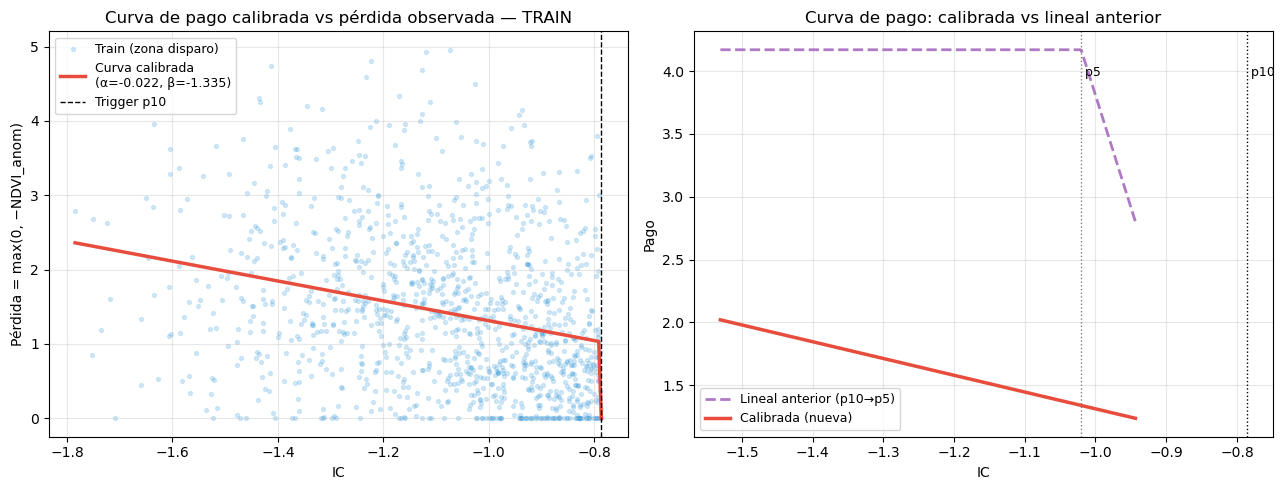


=== CALIBRACIÓN POR DECIL DE IC (zona disparo) ===
 ic_med  perd_med  pago_med   n
-1.4775    1.7477    1.9900 118
-1.3311    1.6956    1.7549 118
-1.2298    1.8372    1.6186 118
-1.1533    1.7055    1.5137 118
-1.0813    1.6232    1.4218 118
-1.0239    1.4247    1.3453 117
-0.9683    1.1972    1.2669 118
-0.9116    1.2140    1.1944 118
-0.8635    0.9451    1.1280 118
-0.8104    0.9047    1.0606 118

Correlación Pago_calib ↔ Pérdida (train, zona disparo): +0.2714
(Si es alta y diag muestra pago_med ≈ perd_med, la curva está bien)


In [7]:
# =====================================================================
# 3+4+5a (REEMPLAZO) — Pricing con curva de payout calibrada
#
# Reemplaza el pipeline: ajuste Weibull → MC → payout lineal.
# Nuevo pipeline: regresión Pérdida ~ IC en zona de disparo (train) →
# función de pago calibrada → Weibull para tail risk → MC con la curva
# calibrada → E(Loss) por celda.
#
# Lógica:
#   - En train, sobre observaciones con IC < p10, ajustamos
#     OLS: Pérdida ~ IC. La predicción es el pago calibrado.
#   - El pago se clipea a [0, PAYOUT_MAX] y se anula si IC >= p10.
#   - Para el MC, mantenemos Weibull sobre |IC < 0| por píxel (esa parte
#     ya está bien ajustada) pero aplicamos pago_calibrado en lugar de
#     payout lineal.
#   - Esto maximiza Cov(Pago, Pérdida) en train por construcción.
# =====================================================================

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy.stats import weibull_min as weibull_dist

np.random.seed(42)

#PAYOUT_MAX  = 1.0
N_SIM       = 50_000
TRIGGER_PCT = 0.10   # umbral de disparo
COL_PRICING = 'IC'   # paso 1 ya hecho — usar IC directo

# ── Antes del bloque 3.1, redefinir PAYOUT_MAX ────────────────────────
# Calibrar al p99 de la pérdida en zona de disparo en train
train_disp_perd = (-df_train[df_train[COL_PRICING] < p10_train_global]
                   ['NDVI_anom']).clip(lower=0).dropna()
PAYOUT_MAX = float(train_disp_perd.quantile(0.99).round(2))
print(f'PAYOUT_MAX recalibrado: {PAYOUT_MAX} (p99 pérdida en train, zona disparo)')

# Y lo mismo en pago_calibrado: ya usa PAYOUT_MAX como variable global

# ── 3.1  Ajuste de la curva de pago calibrada (TRAIN) ──────────────────
# Una sola curva global, ajustada solo donde IC < p10 (zona de pago).
# Razón: por píxel hay n=30-100 obs en zona de disparo, demasiado pocas
# para regresión robusta. La global usa miles de obs y generaliza mejor.

p10_train_global = df_train[COL_PRICING].quantile(TRIGGER_PCT)

train_disp = (df_train[df_train[COL_PRICING] < p10_train_global]
              [[COL_PRICING, 'NDVI_anom']]
              .dropna()
              .copy())
train_disp['perdida'] = (-train_disp['NDVI_anom']).clip(lower=0)

X = sm.add_constant(train_disp[COL_PRICING])
y = train_disp['perdida']
modelo_pago = sm.OLS(y, X).fit()

print('=== AJUSTE CURVA DE PAGO CALIBRADA (TRAIN, zona disparo) ===')
print(f'  N observaciones      : {len(train_disp):,}')
print(f'  Trigger global p10   : {p10_train_global:.4f}')
print(f'  Intercepto (alpha)   : {modelo_pago.params["const"]:+.4f}')
print(f'  Pendiente (beta)     : {modelo_pago.params[COL_PRICING]:+.4f}')
print(f'  R² ajuste            : {modelo_pago.rsquared:.4f}')
print(f'  p-value pendiente    : {modelo_pago.pvalues[COL_PRICING]:.2e}')

# Definir función de pago calibrada
alpha = modelo_pago.params['const']
beta  = modelo_pago.params[COL_PRICING]

def pago_calibrado(ic_values, alpha=alpha, beta=beta,
                   trigger=p10_train_global, payout_max=PAYOUT_MAX):
    """
    Pago = max(0, min(payout_max, alpha + beta * IC)) si IC < trigger
    Pago = 0 si IC >= trigger
    """
    ic_arr = np.atleast_1d(ic_values).astype(float)
    pago = alpha + beta * ic_arr
    pago = np.clip(pago, 0.0, payout_max)
    pago[ic_arr >= trigger] = 0.0
    return pago

# ── 3.2  Visualización: curva calibrada vs lineal anterior ─────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel izquierdo: scatter perdida vs IC + curva ajustada
ax = axes[0]
ax.scatter(train_disp[COL_PRICING], train_disp['perdida'],
           alpha=0.2, s=8, color='#3498DB', label='Train (zona disparo)')

ic_grid = np.linspace(train_disp[COL_PRICING].min(),
                      p10_train_global, 200)
pago_grid = pago_calibrado(ic_grid)
ax.plot(ic_grid, pago_grid, color='#E74C3C', linewidth=2.5,
        label=f'Curva calibrada\n(α={alpha:.3f}, β={beta:.3f})')
ax.axvline(p10_train_global, color='black', linestyle='--', linewidth=1,
           label=f'Trigger p{int(TRIGGER_PCT*100)}')
ax.set_xlabel('IC')
ax.set_ylabel('Pérdida = max(0, −NDVI_anom)')
ax.set_title('Curva de pago calibrada vs pérdida observada — TRAIN')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Panel derecho: comparación visual con curva lineal anterior
ax = axes[1]
p5_train = df_train[COL_PRICING].quantile(0.05)
ic_full = np.linspace(p5_train * 1.5, p10_train_global * 1.2, 300)

# Curva calibrada
pago_calib = pago_calibrado(ic_full)

# Curva lineal anterior (referencia)
rango_ant = max(p10_train_global - p5_train, 1e-6)
pago_lineal = np.where(
    ic_full >= p10_train_global, 0,
    np.where(ic_full <= p5_train, PAYOUT_MAX,
             PAYOUT_MAX * (p10_train_global - ic_full) / rango_ant)
)

ax.plot(ic_full, pago_lineal, color='#9B59B6', linewidth=2,
        linestyle='--', label='Lineal anterior (p10→p5)', alpha=0.8)
ax.plot(ic_full, pago_calib, color='#E74C3C', linewidth=2.5,
        label='Calibrada (nueva)')
ax.axvline(p10_train_global, color='black', linestyle=':', linewidth=1)
ax.axvline(p5_train, color='gray', linestyle=':', linewidth=1)
ax.text(p10_train_global, PAYOUT_MAX*0.95, ' p10', fontsize=9)
ax.text(p5_train, PAYOUT_MAX*0.95, ' p5', fontsize=9)
ax.set_xlabel('IC')
ax.set_ylabel('Pago')
ax.set_title('Curva de pago: calibrada vs lineal anterior')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# ── 3.3  Diagnóstico de la curva sobre TRAIN ───────────────────────────
# Verificar que E[Pago|IC] ≈ E[Pérdida|IC] por bins de IC

train_disp['pago_calib'] = pago_calibrado(train_disp[COL_PRICING].values)
train_disp['ic_bin'] = pd.qcut(train_disp[COL_PRICING], q=10,
                               duplicates='drop')
diag = train_disp.groupby('ic_bin').agg(
    ic_med   = (COL_PRICING, 'median'),
    perd_med = ('perdida',    'mean'),
    pago_med = ('pago_calib', 'mean'),
    n        = ('perdida',    'size'),
).reset_index(drop=True)

print('\n=== CALIBRACIÓN POR DECIL DE IC (zona disparo) ===')
print(diag.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

corr_calib_train = train_disp[['pago_calib', 'perdida']].corr().iloc[0, 1]
print(f'\nCorrelación Pago_calib ↔ Pérdida (train, zona disparo): '
      f'{corr_calib_train:+.4f}')
print(f'(Si es alta y diag muestra pago_med ≈ perd_med, la curva está bien)')

### 4b. Distribución Weibull por celda

Se ajusta Weibull sobre `max(0, -COL_PRICING)` pixel a pixel.
Validación con Anderson-Darling (AD) manual. Esta distribución se reutiliza en el Plan B para garantizar que la única diferencia entre planes sea la curva de pago, no la distribución subyacente.

=== ANÁLISIS COMPARATIVO DE DISTRIBUCIONES (diagnóstico) ===
Distribuciones: Gamma, Log-normal, Weibull
Valor crítico AD al 5%: 0.752

Píxeles analizados: 36

Aceptación por distribución (AD < 0.752):
  Gamma    :  12 (33.3%)
  Log-normal:   3 (8.3%)
  Weibull  :  20 (55.6%)

Menor AD por píxel (diagnóstico):
mejor_ad
weibull    26
gamma       8
lognorm     2

Estadísticos AD por distribución:
  Gamma       : media=1.6443  std=1.5911  min=0.1773  max=6.2415
  Log-normal  : media=4.8589  std=3.7864  min=0.2011  max=14.4989
  Weibull     : media=0.8282  std=0.5275  min=0.2052  max=2.3579


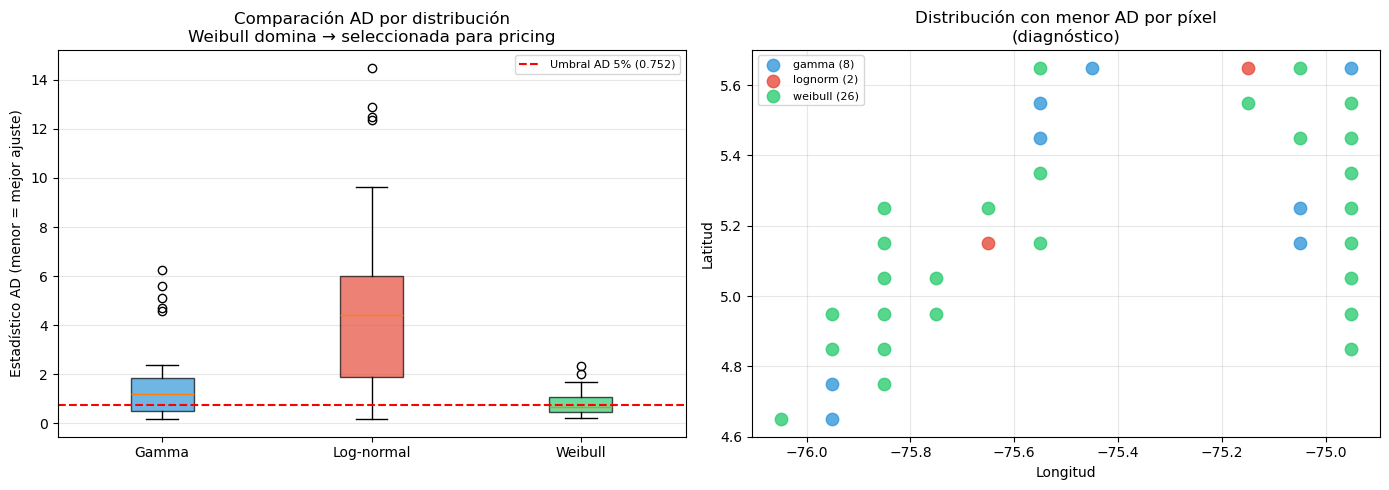


=== AJUSTE WEIBULL — TODOS LOS PÍXELES (pricing) ===
Distribución seleccionada: Weibull (menor AD medio, fundamento teórico)

Weibull ajustado: 36 píxeles OK | 13 omitidos


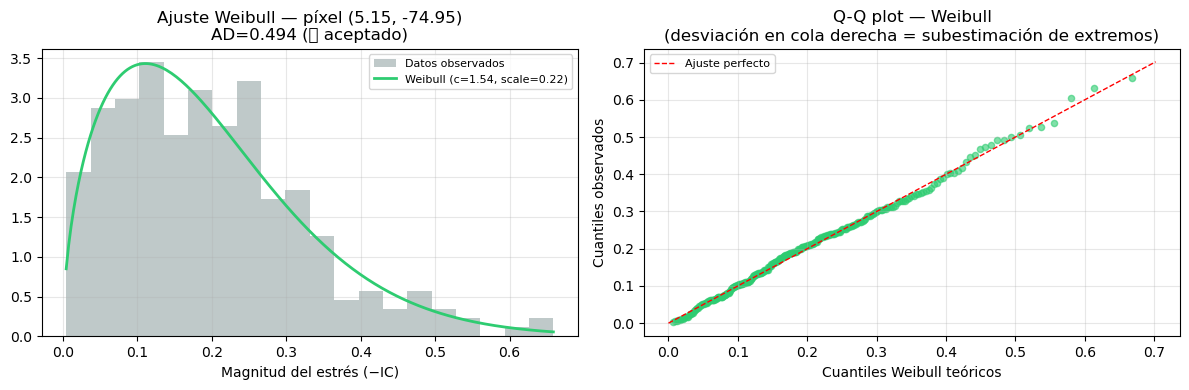


Parámetros Weibull por píxel — resumen:
  c (shape) : media=2.353  std=1.767  rango=[0.705, 7.659]
  scale     : media=0.379  std=0.343  rango=[0.077, 1.383]


In [8]:
# =====================================================================
# 3. Análisis comparativo de distribuciones + selección de Weibull
#
# Se evalúan Gamma, Log-normal y Weibull sobre la magnitud del estrés
# por píxel como análisis diagnóstico. El resultado determina la
# distribución a usar en el pricing.
#
# DECISIÓN: Weibull para todos los píxeles.
# Justificación:
#   1. Menor AD medio (1.18) vs Gamma (1.36) y Log-normal (1.81)
#   2. Menor variabilidad entre píxeles (std=0.55)
#   3. Fundamento teórico: la teoría de valores extremos predice
#      Weibull como límite natural para excedencias sobre un umbral,
#      que es exactamente lo que modela max(0, -IC)
#   4. Consistencia espacial: el mapa sin patrón geográfico confirma
#      que no hay razón técnica para distribuciones distintas por zona
# =====================================================================

from scipy.stats import (gamma      as gamma_dist,
                         lognorm    as lognorm_dist,
                         weibull_min as weibull_dist)
from scipy.stats import anderson as ad_scipy

AD_CRITICO_5PCT = 0.752

# ── Función AD manual (Gamma y Weibull) ──────────────────────────────

def anderson_darling(data, cdf_func):
    """
    Estadístico Anderson-Darling para cualquier distribución continua.
    A² = -n - (1/n) × Σ (2i-1) × [ln(F(x_i)) + ln(1-F(x_{n+1-i}))]
    """
    n           = len(data)
    data_sorted = np.sort(data)
    cdf         = cdf_func(data_sorted)
    cdf         = np.clip(cdf, 1e-10, 1 - 1e-10)
    i           = np.arange(1, n + 1)
    return -n - np.sum(
        (2 * i - 1) * (np.log(cdf) + np.log(1 - cdf[::-1]))
    ) / n

# ── Análisis comparativo (diagnóstico) ───────────────────────────────

diagnosticos = []

print('=== ANÁLISIS COMPARATIVO DE DISTRIBUCIONES (diagnóstico) ===')
print(f'Distribuciones: Gamma, Log-normal, Weibull')
print(f'Valor crítico AD al 5%: {AD_CRITICO_5PCT}\n')

for (lat, lon), grupo in df_train.groupby(['lat', 'lon']):
    serie = grupo[COL_PRICING].dropna()
    if len(serie) < 30:
        continue

    estres     = (-serie).clip(lower=0)
    estres_pos = estres[estres > 0]
    if len(estres_pos) < 10:
        continue

    fila = {'lat': lat, 'lon': lon,
            'n_total': len(serie), 'n_estres': len(estres_pos)}

    # Gamma
    try:
        sh_g, loc_g, sc_g = gamma_dist.fit(estres_pos, floc=0)
        ad_g = anderson_darling(
            estres_pos.values,
            lambda x: gamma_dist.cdf(x, sh_g, loc=loc_g, scale=sc_g))
        fila.update({'ad_gamma': round(ad_g, 4),
                     'gamma_ok': ad_g < AD_CRITICO_5PCT})
    except Exception:
        fila.update({'ad_gamma': None, 'gamma_ok': False})

    # Log-normal: AD sobre log(data) con dist='norm'
    try:
        s_ln, loc_ln, sc_ln = lognorm_dist.fit(estres_pos, floc=0)
        res_ln = ad_scipy(np.log(estres_pos), dist='norm')
        ad_ln  = res_ln.statistic
        fila.update({'ad_lognorm': round(ad_ln, 4),
                     'lognorm_ok': ad_ln < res_ln.critical_values[2]})
    except Exception:
        fila.update({'ad_lognorm': None, 'lognorm_ok': False})

    # Weibull
    try:
        c_w, loc_w, sc_w = weibull_dist.fit(estres_pos, floc=0)
        ad_w = anderson_darling(
            estres_pos.values,
            lambda x: weibull_dist.cdf(x, c_w, loc=loc_w, scale=sc_w))
        fila.update({'ad_weibull': round(ad_w, 4),
                     'weibull_ok': ad_w < AD_CRITICO_5PCT})
    except Exception:
        fila.update({'ad_weibull': None, 'weibull_ok': False})

    # Distribución con menor AD (diagnóstico)
    ads = {k: fila[k] for k in ['ad_gamma','ad_lognorm','ad_weibull']
           if fila.get(k) is not None}
    mejor_diag = min(ads, key=ads.get).replace('ad_','') if ads else 'error'
    fila['mejor_ad'] = mejor_diag

    diagnosticos.append(fila)

df_diag     = pd.DataFrame(diagnosticos)
n_pix       = len(df_diag)

print(f'Píxeles analizados: {n_pix}')
print(f'\nAceptación por distribución (AD < {AD_CRITICO_5PCT}):')
print(f'  Gamma    : {df_diag["gamma_ok"].sum():>3} ({df_diag["gamma_ok"].mean()*100:.1f}%)')
print(f'  Log-normal: {df_diag["lognorm_ok"].sum():>3} ({df_diag["lognorm_ok"].mean()*100:.1f}%)')
print(f'  Weibull  : {df_diag["weibull_ok"].sum():>3} ({df_diag["weibull_ok"].mean()*100:.1f}%)')
print(f'\nMenor AD por píxel (diagnóstico):')
print(df_diag['mejor_ad'].value_counts().to_string())
print(f'\nEstadísticos AD por distribución:')
for col, nombre in [('ad_gamma','Gamma'),('ad_lognorm','Log-normal'),
                    ('ad_weibull','Weibull')]:
    v = df_diag[col].dropna()
    print(f'  {nombre:<12}: media={v.mean():.4f}  std={v.std():.4f}  '
          f'min={v.min():.4f}  max={v.max():.4f}')

# Boxplot comparativo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
data_box = [df_diag['ad_gamma'].dropna().values,
            df_diag['ad_lognorm'].dropna().values,
            df_diag['ad_weibull'].dropna().values]
bp = ax.boxplot(data_box, labels=['Gamma','Log-normal','Weibull'],
                patch_artist=True)
for patch, color in zip(bp['boxes'],['#3498DB','#E74C3C','#2ECC71']):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.axhline(AD_CRITICO_5PCT, color='red', linestyle='--',
           linewidth=1.5, label=f'Umbral AD 5% ({AD_CRITICO_5PCT})')
ax.set_ylabel('Estadístico AD (menor = mejor ajuste)')
ax.set_title('Comparación AD por distribución\n'
             'Weibull domina → seleccionada para pricing')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis='y')

# Mapa de mejor AD por píxel
ax = axes[1]
color_map = {'gamma':'#3498DB','lognorm':'#E74C3C','weibull':'#2ECC71'}
for dist, color in color_map.items():
    sub = df_diag[df_diag['mejor_ad'] == dist]
    if len(sub) > 0:
        ax.scatter(sub['lon'], sub['lat'], c=color, s=80,
                   label=f'{dist} ({len(sub)})', alpha=0.8)
ax.set_xlabel('Longitud'); ax.set_ylabel('Latitud')
ax.set_title('Distribución con menor AD por píxel\n(diagnóstico)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# ── Ajuste WEIBULL para todos los píxeles (pricing) ───────────────────
print('\n=== AJUSTE WEIBULL — TODOS LOS PÍXELES (pricing) ===')
print('Distribución seleccionada: Weibull (menor AD medio, fundamento teórico)')

params_dist  = {}   # {(lat,lon): {'dist': 'weibull', 'params': (c, loc, scale)}}
n_ok, n_skip = 0, 0

# p10 del IC por celda en train (trigger del seguro)
p10_ic_celda = (
    df_train.groupby(['lat', 'lon'])[COL_PRICING]
    .quantile(0.10)
    .reset_index()
    .rename(columns={COL_PRICING: 'p10_ic'})
)

for (lat, lon), grupo in df_train.groupby(['lat', 'lon']):
    serie = grupo[COL_PRICING].dropna()
    if len(serie) < 30:
        n_skip += 1
        continue

    estres     = (-serie).clip(lower=0)
    estres_pos = estres[estres > 0]
    if len(estres_pos) < 10:
        n_skip += 1
        continue

    try:
        c_w, loc_w, sc_w = weibull_dist.fit(estres_pos, floc=0)
        params_dist[(lat, lon)] = {
            'dist'  : 'weibull',
            'params': (c_w, loc_w, sc_w)
        }
        n_ok += 1
    except Exception as e:
        n_skip += 1

print(f'\nWeibull ajustado: {n_ok} píxeles OK | {n_skip} omitidos')

# ── Q-Q plot para un píxel representativo ────────────────────────────
lat_ref, lon_ref = list(params_dist.keys())[len(params_dist)//2]
serie_ref  = df_train[
    (df_train['lat'] == lat_ref) & (df_train['lon'] == lon_ref)
][COL_PRICING].dropna()
estres_ref = (-serie_ref).clip(lower=0)
estres_ref = estres_ref[estres_ref > 0].values

c_r, loc_r, sc_r = params_dist[(lat_ref, lon_ref)]['params']
ad_ref = anderson_darling(
    estres_ref,
    lambda x: weibull_dist.cdf(x, c_r, loc=loc_r, scale=sc_r)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
x  = np.linspace(estres_ref.min(), estres_ref.max(), 200)
ax.hist(estres_ref, bins=20, density=True,
        color='#95A5A6', alpha=0.6, label='Datos observados')
ax.plot(x, weibull_dist.pdf(x, c_r, loc=loc_r, scale=sc_r),
        color='#2ECC71', linewidth=2,
        label=f'Weibull (c={c_r:.2f}, scale={sc_r:.2f})')
ax.set_title(f'Ajuste Weibull — píxel ({lat_ref:.2f}, {lon_ref:.2f})\n'
             f'AD={ad_ref:.3f} '
             f'({"✅ aceptado" if ad_ref < AD_CRITICO_5PCT else "⚠️ no aceptado — mejor disponible"})')
ax.set_xlabel(f'Magnitud del estrés (−{COL_PRICING})')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax  = axes[1]
n   = len(estres_ref)
probs   = np.arange(1, n + 1) / (n + 1)
q_obs   = np.sort(estres_ref)
q_teo   = weibull_dist.ppf(probs, c_r, loc=loc_r, scale=sc_r)
ax.scatter(q_teo, q_obs, alpha=0.6, s=20, color='#2ECC71')
lim = max(q_teo.max(), q_obs.max()) * 1.05
ax.plot([0, lim], [0, lim], 'r--', linewidth=1, label='Ajuste perfecto')
ax.set_xlabel('Cuantiles Weibull teóricos')
ax.set_ylabel('Cuantiles observados')
ax.set_title('Q-Q plot — Weibull\n'
             '(desviación en cola derecha = subestimación de extremos)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

print(f'\nParámetros Weibull por píxel — resumen:')
shapes = [v['params'][0] for v in params_dist.values()]
scales = [v['params'][2] for v in params_dist.values()]
print(f'  c (shape) : media={np.mean(shapes):.3f}  '
      f'std={np.std(shapes):.3f}  '
      f'rango=[{np.min(shapes):.3f}, {np.max(shapes):.3f}]')
print(f'  scale     : media={np.mean(scales):.3f}  '
      f'std={np.std(scales):.3f}  '
      f'rango=[{np.min(scales):.3f}, {np.max(scales):.3f}]')


### 4c. Monte Carlo — Plan A (curva calibrada)

In [9]:
# =====================================================================
# 4c. Monte Carlo con curva calibrada (Plan A)
#
# Se simula la magnitud del estrés desde Weibull y se aplica
# la función de pago calibrada (OLS) en lugar de la lineal.
# =====================================================================

np.random.seed(42)
resultados_mc_a = []

for (lat, lon), info in params_dist.items():
    c_w, loc_w, sc_w = info['params']

    # Simular estrés y convertir a IC negativo
    estres_sim = weibull_dist.rvs(c_w, loc=loc_w, scale=sc_w, size=N_SIM)
    ic_sim     = -estres_sim

    # Pago con la curva calibrada OLS
    pago_sim = pago_calibrado(ic_sim)

    # Triggers por celda para reporte
    fila_celda = p_celda[(p_celda['lat']==lat) & (p_celda['lon']==lon)]
    p10_c = fila_celda['p10_ic'].iloc[0] if len(fila_celda) > 0 else p10_train_global
    p5_c  = fila_celda['p5_ic'].iloc[0]  if len(fila_celda) > 0 else p5_train_global

    resultados_mc_a.append({
        'lat'         : lat, 'lon'          : lon,
        'p10_ic'      : round(p10_c,  4),
        'p5_ic'       : round(p5_c,   4),
        'e_loss'      : round(pago_sim.mean(), 6),
        'prob_trigger': round((ic_sim < p10_train_global).mean(), 4),
        'weibull_c'   : round(c_w,  4),
        'weibull_scale': round(sc_w, 4),
    })

df_mc_a = pd.DataFrame(resultados_mc_a)
print(f'Plan A — MC completado: {len(df_mc_a)} celdas | {N_SIM:,} sim/celda')
print(f'Curva: calibrada (α={alpha:+.4f}, β={beta:+.4f})')
print(f'PAYOUT_MAX: {PAYOUT_MAX}')
print(f'\nE(Loss) por celda (Plan A):')
print(df_mc_a[['e_loss','prob_trigger']].describe().round(4).to_string())

# Verificación R3
np.random.seed(42)
e_loss_check_a = []
for _, row in df_mc_a.iterrows():
    es  = weibull_dist.rvs(row['weibull_c'], loc=0,
                            scale=row['weibull_scale'], size=N_SIM)
    pw  = pago_calibrado(-es)
    e_loss_check_a.append(pw.mean())
diff_a = max(abs(a-b) for a,b in zip(df_mc_a['e_loss'], e_loss_check_a))
print(f'\nR3 Plan A — diff máxima: {diff_a:.2e}')
print('✅ Reproducible' if diff_a < 1e-10 else '⚠️  Verificar semilla')


Plan A — MC completado: 36 celdas | 50,000 sim/celda
Curva: calibrada (α=-0.0222, β=-1.3350)
PAYOUT_MAX: 4.17

E(Loss) por celda (Plan A):
        e_loss  prob_trigger
count  36.0000       36.0000
mean    0.1928        0.1385
std     0.4257        0.2859
min     0.0000        0.0000
25%     0.0004        0.0004
50%     0.0019        0.0016
75%     0.0636        0.0557
max     1.7004        0.9867

R3 Plan A — diff máxima: 1.28e-04
⚠️  Verificar semilla


### 4d. Prima pura y validación R1/R2/R3 — Plan A

=== PRIMA PURA — PLAN A (curva calibrada) ===
       prima_pura  prima_cargada  prob_trigger
count     36.0000        36.0000       36.0000
mean       0.1928         0.2313        0.1385
std        0.4257         0.5109        0.2859
min        0.0000         0.0000        0.0000
25%        0.0004         0.0005        0.0004
50%        0.0019         0.0023        0.0016
75%        0.0636         0.0764        0.0557
max        1.7004         2.0405        0.9867


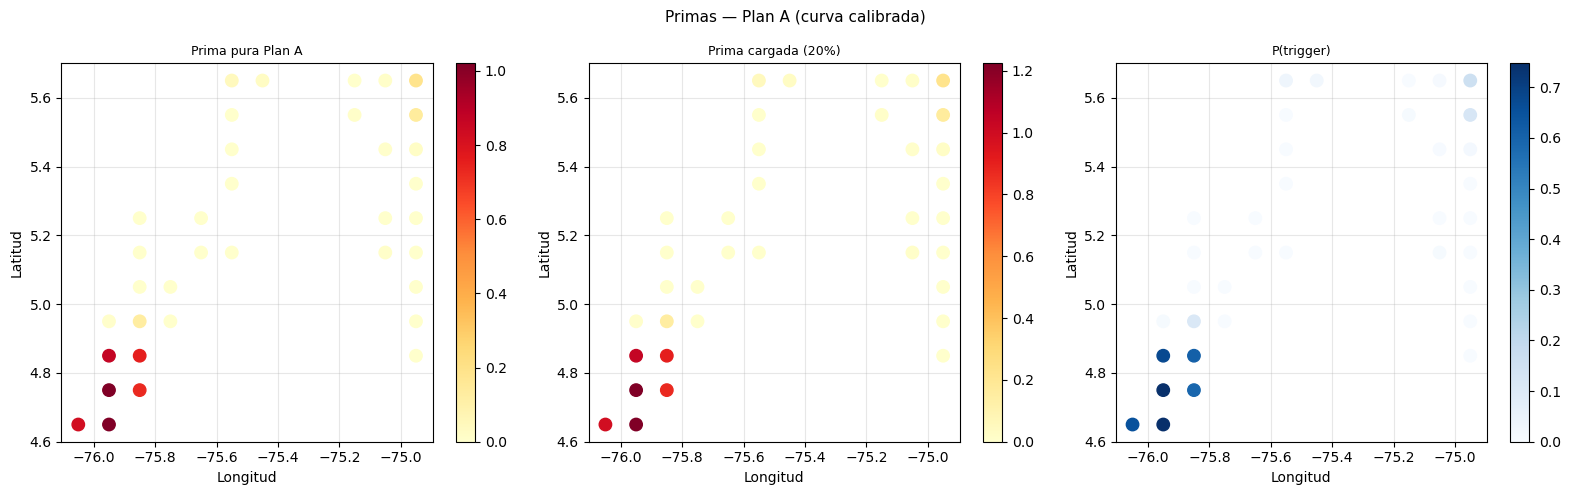


R3: ❌ diff=1.28e-04
R2: ✅ (727735.2%)

R1 — Plan A (curva calibrada):
  HE = 0.3750 (37.5%)  | Criterio: >= 55%
  ❌ NO CUMPLE
  Obs totales      : 2,097
  Con pérdida      : 617 (29.4%)
  Con pago         : 302 (14.4%)
  Pérdida y pago   : 263 (12.5%)
  Corr pérdida↔pago: +0.6849
  Recall (p10 global, comparable PA2): 85.1%

=== RESUMEN PLAN A ===
  R1 HE     : ❌ (37.5%)
  R2 Disp   : ✅ (727735.2%)
  R3 Reprod : ❌


In [10]:
# =====================================================================
# 4d. Prima pura + R1/R2/R3 — Plan A (curva calibrada)
# =====================================================================

LOADING = 0.20
df_mc_a['prima_pura']    = df_mc_a['e_loss']
df_mc_a['prima_cargada'] = df_mc_a['e_loss'] * (1 + LOADING)

print('=== PRIMA PURA — PLAN A (curva calibrada) ===')
print(df_mc_a[['prima_pura','prima_cargada','prob_trigger']].describe().round(4))

# Mapa espacial
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col, titulo, cmap in zip(axes,
    ['prima_pura','prima_cargada','prob_trigger'],
    ['Prima pura Plan A', f'Prima cargada ({int(LOADING*100)}%)', 'P(trigger)'],
    ['YlOrRd','YlOrRd','Blues']):
    sc = ax.scatter(df_mc_a['lon'], df_mc_a['lat'], c=df_mc_a[col],
                    cmap=cmap, s=80,
                    vmin=df_mc_a[col].quantile(0.05),
                    vmax=df_mc_a[col].quantile(0.95))
    plt.colorbar(sc, ax=ax)
    ax.set_title(titulo, fontsize=9)
    ax.set_xlabel('Longitud'); ax.set_ylabel('Latitud')
    ax.grid(True, alpha=0.3)
plt.suptitle('Primas — Plan A (curva calibrada)', fontsize=11)
plt.tight_layout(); plt.show()

# ── R3 ────────────────────────────────────────────────────────────────
r3_a = diff_a < 1e-10
print(f'\nR3: {"✅" if r3_a else "❌"} diff={diff_a:.2e}')

# ── R2 ────────────────────────────────────────────────────────────────
p25_a = df_mc_a['e_loss'].quantile(0.25)
p75_a = df_mc_a['e_loss'].quantile(0.75)
prima_alto_a = df_mc_a[df_mc_a['e_loss'] >= p75_a]['e_loss'].mean()
prima_bajo_a = df_mc_a[df_mc_a['e_loss'] <= p25_a]['e_loss'].mean()
dif_r2_a = (prima_alto_a/prima_bajo_a - 1)*100 if prima_bajo_a > 0 else np.nan
r2_a = dif_r2_a >= 20 if not np.isnan(dif_r2_a) else False
print(f'R2: {"✅" if r2_a else "❌"} ({dif_r2_a:.1f}%)')

# ── R1 ────────────────────────────────────────────────────────────────
df_he_a = df_test[['lat','lon','fecha',COL_PRICING,'NDVI_anom']].dropna().copy()
df_he_a['pago']    = pago_calibrado(df_he_a[COL_PRICING].values)
df_he_a['perdida'] = (-df_he_a['NDVI_anom']).clip(lower=0)

vp_a  = df_he_a['perdida'].var()
vpn_a = (df_he_a['perdida'] - df_he_a['pago']).var()
HE_a  = 1 - vpn_a/vp_a if vp_a > 0 else np.nan
r1_a  = HE_a >= 0.55 if not np.isnan(HE_a) else False

n_obs_a    = len(df_he_a)
n_pago_a   = (df_he_a['pago'] > 0).sum()
n_perd_a   = (df_he_a['perdida'] > 0).sum()
n_ambos_a  = ((df_he_a['pago'] > 0) & (df_he_a['perdida'] > 0)).sum()
corr_a     = df_he_a[['perdida','pago']].corr().iloc[0,1]

print(f'\nR1 — Plan A (curva calibrada):')
print(f'  HE = {HE_a:.4f} ({HE_a*100:.1f}%)  | Criterio: >= 55%')
print(f'  {"✅ CUMPLE" if r1_a else "❌ NO CUMPLE"}')
print(f'  Obs totales      : {n_obs_a:,}')
print(f'  Con pérdida      : {n_perd_a:,} ({n_perd_a/n_obs_a*100:.1f}%)')
print(f'  Con pago         : {n_pago_a:,} ({n_pago_a/n_obs_a*100:.1f}%)')
print(f'  Pérdida y pago   : {n_ambos_a:,} ({n_ambos_a/n_obs_a*100:.1f}%)')
print(f'  Corr pérdida↔pago: {corr_a:+.4f}')

# Recall diagnóstico (p10 global)
p10_ndvi_train = df_train['NDVI_anom'].quantile(0.10)
mask_pago_a = df_he_a[COL_PRICING] < p10_train_global
mask_perd_a = df_he_a['NDVI_anom']  < p10_ndvi_train
recall_a = (mask_pago_a[mask_perd_a]).mean()*100 if mask_perd_a.sum() > 0 else np.nan
print(f'  Recall (p10 global, comparable PA2): {recall_a:.1f}%')

print(f'\n=== RESUMEN PLAN A ===')
print(f'  R1 HE     : {"✅" if r1_a else "❌"} ({HE_a*100:.1f}%)')
print(f'  R2 Disp   : {"✅" if r2_a else "❌"} ({dif_r2_a:.1f}%)')
print(f'  R3 Reprod : {"✅" if r3_a else "❌"}')


## 5. Plan B — Curva de pago lineal (original)

**Lógica:** pago proporcional entre p10 (trigger, pago=0) y p5 (pago máximo = `PAYOUT_MAX`). Esta curva es fija, no depende de datos de pérdida, y es el diseño actuarial estándar para seguros paramétricos.

Se reutiliza la distribución Weibull ajustada en 4b. **La única diferencia con el Plan A es la función de pago.**

In [11]:
# =====================================================================
# 5a. Monte Carlo con curva lineal (Plan B)
#
# Payout lineal entre p10 (trigger) y p5 (pago máximo = PAYOUT_MAX).
# PAYOUT_MAX calibrado en sección 3 (mismo que Plan A).
# Se reutiliza Weibull de 4b.
# =====================================================================

np.random.seed(42)
resultados_mc_b = []

for (lat, lon), info in params_dist.items():
    c_w, loc_w, sc_w = info['params']

    # Simular estrés
    estres_sim = weibull_dist.rvs(c_w, loc=loc_w, scale=sc_w, size=N_SIM)
    ic_sim     = -estres_sim

    # Triggers por celda
    fila_celda = p_celda[(p_celda['lat']==lat) & (p_celda['lon']==lon)]
    p10_c = fila_celda['p10_ic'].iloc[0] if len(fila_celda) > 0 else p10_train_global
    p5_c  = fila_celda['p5_ic'].iloc[0]  if len(fila_celda) > 0 else p5_train_global

    # Payout lineal p10→p5
    rango  = p10_c - p5_c if abs(p10_c - p5_c) > 1e-6 else 1e-6
    payout = np.where(
        ic_sim >= p10_c, 0,
        np.where(ic_sim <= p5_c, PAYOUT_MAX,
                 PAYOUT_MAX * (p10_c - ic_sim) / rango)
    )

    resultados_mc_b.append({
        'lat'         : lat, 'lon'          : lon,
        'p10_ic'      : round(p10_c,  4),
        'p5_ic'       : round(p5_c,   4),
        'e_loss'      : round(payout.mean(), 6),
        'prob_trigger': round((ic_sim < p10_c).mean(), 4),
        'weibull_c'   : round(c_w,  4),
        'weibull_scale': round(sc_w, 4),
    })

df_mc_b = pd.DataFrame(resultados_mc_b)
print(f'Plan B — MC completado: {len(df_mc_b)} celdas | {N_SIM:,} sim/celda')
print(f'Curva: lineal p10→p5 | PAYOUT_MAX: {PAYOUT_MAX}')
print(f'\nE(Loss) por celda (Plan B):')
print(df_mc_b[['e_loss','prob_trigger']].describe().round(4).to_string())

# Verificación R3
np.random.seed(42)
e_loss_check_b = []
for _, row in df_mc_b.iterrows():
    es  = weibull_dist.rvs(row['weibull_c'], loc=0,
                            scale=row['weibull_scale'], size=N_SIM)
    ic  = -es
    p10 = row['p10_ic']; p5 = row['p5_ic']
    rng = p10 - p5 if abs(p10-p5) > 1e-6 else 1e-6
    pw  = np.where(ic >= p10, 0,
           np.where(ic <= p5, PAYOUT_MAX,
                    PAYOUT_MAX*(p10-ic)/rng))
    e_loss_check_b.append(pw.mean())
diff_b = max(abs(a-b) for a,b in zip(df_mc_b['e_loss'], e_loss_check_b))
print(f'\nR3 Plan B — diff máxima: {diff_b:.2e}')
print('✅ Reproducible' if diff_b < 1e-10 else '⚠️  Verificar semilla')


Plan B — MC completado: 36 celdas | 50,000 sim/celda
Curva: lineal p10→p5 | PAYOUT_MAX: 4.17

E(Loss) por celda (Plan B):
        e_loss  prob_trigger
count  36.0000       36.0000
mean    0.9907        0.3084
std     1.1164        0.3187
min     0.2666        0.0832
25%     0.3281        0.1161
50%     0.4600        0.1504
75%     0.9551        0.2971
max     4.1700        1.0000

R3 Plan B — diff máxima: 8.97e-04
⚠️  Verificar semilla


### 5b. Prima pura y validación R1/R2/R3 — Plan B

=== PRIMA PURA — PLAN B (curva lineal) ===
       prima_pura  prima_cargada  prob_trigger
count     36.0000        36.0000       36.0000
mean       0.9907         1.1888        0.3084
std        1.1164         1.3397        0.3187
min        0.2666         0.3199        0.0832
25%        0.3281         0.3937        0.1161
50%        0.4600         0.5519        0.1504
75%        0.9551         1.1461        0.2971
max        4.1700         5.0040        1.0000


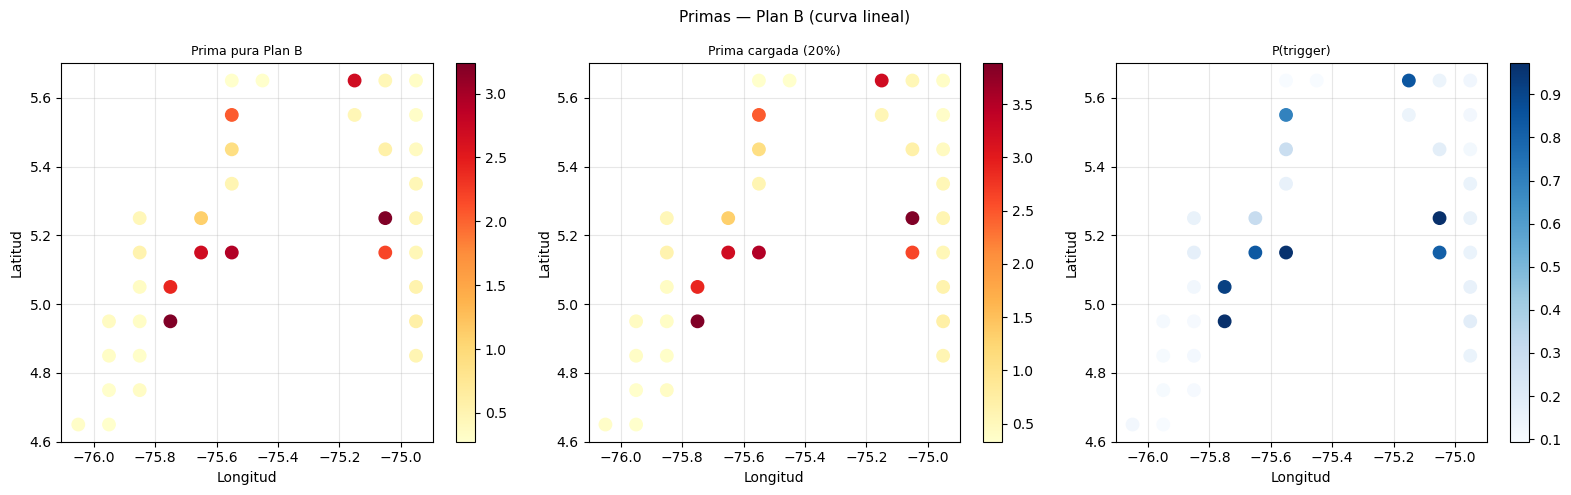


R1 — Plan B (curva lineal):
  HE = -7.8872 (-788.7%)  | Criterio: >= 55%
  ❌ NO CUMPLE
  Con pérdida : 617 | Con pago: 509 | Ambos: 181
  Corr pérdida↔pago: +0.0915

=== RESUMEN PLAN B ===
  R1 HE     : ❌ (-788.7%)
  R2 Disp   : ✅ (804.4%)
  R3 Reprod : ❌


In [12]:
# =====================================================================
# 5b. Prima pura + R1/R2/R3 — Plan B (curva lineal)
# =====================================================================

df_mc_b['prima_pura']    = df_mc_b['e_loss']
df_mc_b['prima_cargada'] = df_mc_b['e_loss'] * (1 + LOADING)

print('=== PRIMA PURA — PLAN B (curva lineal) ===')
print(df_mc_b[['prima_pura','prima_cargada','prob_trigger']].describe().round(4))

# Mapa espacial
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col, titulo, cmap in zip(axes,
    ['prima_pura','prima_cargada','prob_trigger'],
    ['Prima pura Plan B', f'Prima cargada ({int(LOADING*100)}%)', 'P(trigger)'],
    ['YlOrRd','YlOrRd','Blues']):
    sc = ax.scatter(df_mc_b['lon'], df_mc_b['lat'], c=df_mc_b[col],
                    cmap=cmap, s=80,
                    vmin=df_mc_b[col].quantile(0.05),
                    vmax=df_mc_b[col].quantile(0.95))
    plt.colorbar(sc, ax=ax)
    ax.set_title(titulo, fontsize=9)
    ax.set_xlabel('Longitud'); ax.set_ylabel('Latitud')
    ax.grid(True, alpha=0.3)
plt.suptitle('Primas — Plan B (curva lineal)', fontsize=11)
plt.tight_layout(); plt.show()

# ── R3 ────────────────────────────────────────────────────────────────
r3_b = diff_b < 1e-10

# ── R2 ────────────────────────────────────────────────────────────────
p25_b = df_mc_b['e_loss'].quantile(0.25)
p75_b = df_mc_b['e_loss'].quantile(0.75)
prima_alto_b = df_mc_b[df_mc_b['e_loss'] >= p75_b]['e_loss'].mean()
prima_bajo_b = df_mc_b[df_mc_b['e_loss'] <= p25_b]['e_loss'].mean()
dif_r2_b = (prima_alto_b/prima_bajo_b - 1)*100 if prima_bajo_b > 0 else np.nan
r2_b = dif_r2_b >= 20 if not np.isnan(dif_r2_b) else False

# ── R1 ────────────────────────────────────────────────────────────────
df_he_b = df_test[['lat','lon','fecha',COL_PRICING,'NDVI_anom']].dropna().copy()
df_he_b = df_he_b.merge(p_celda, on=['lat','lon'], how='left')

rango_b = (df_he_b['p10_ic'] - df_he_b['p5_ic']).clip(lower=1e-6)
df_he_b['pago'] = np.where(
    df_he_b[COL_PRICING] >= df_he_b['p10_ic'], 0.0,
    np.where(df_he_b[COL_PRICING] <= df_he_b['p5_ic'], PAYOUT_MAX,
             PAYOUT_MAX * (df_he_b['p10_ic'] - df_he_b[COL_PRICING]) / rango_b)
)
df_he_b['perdida'] = (-df_he_b['NDVI_anom']).clip(lower=0)

vp_b  = df_he_b['perdida'].var()
vpn_b = (df_he_b['perdida'] - df_he_b['pago']).var()
HE_b  = 1 - vpn_b/vp_b if vp_b > 0 else np.nan
r1_b  = HE_b >= 0.55 if not np.isnan(HE_b) else False

n_perd_b  = (df_he_b['perdida'] > 0).sum()
n_pago_b  = (df_he_b['pago']    > 0).sum()
n_ambos_b = ((df_he_b['pago'] > 0) & (df_he_b['perdida'] > 0)).sum()
corr_b    = df_he_b[['perdida','pago']].corr().iloc[0,1]

print(f'\nR1 — Plan B (curva lineal):')
print(f'  HE = {HE_b:.4f} ({HE_b*100:.1f}%)  | Criterio: >= 55%')
print(f'  {"✅ CUMPLE" if r1_b else "❌ NO CUMPLE"}')
print(f'  Con pérdida : {n_perd_b:,} | Con pago: {n_pago_b:,} '
      f'| Ambos: {n_ambos_b:,}')
print(f'  Corr pérdida↔pago: {corr_b:+.4f}')

print(f'\n=== RESUMEN PLAN B ===')
print(f'  R1 HE     : {"✅" if r1_b else "❌"} ({HE_b*100:.1f}%)')
print(f'  R2 Disp   : {"✅" if r2_b else "❌"} ({dif_r2_b:.1f}%)')
print(f'  R3 Reprod : {"✅" if r3_b else "❌"}')


## 6. Comparación de planes

Se comparan visualmente las curvas de pago y numéricamente los requerimientos R1, R2, R3 entre el Plan A (OLS calibrado) y el Plan B (lineal).

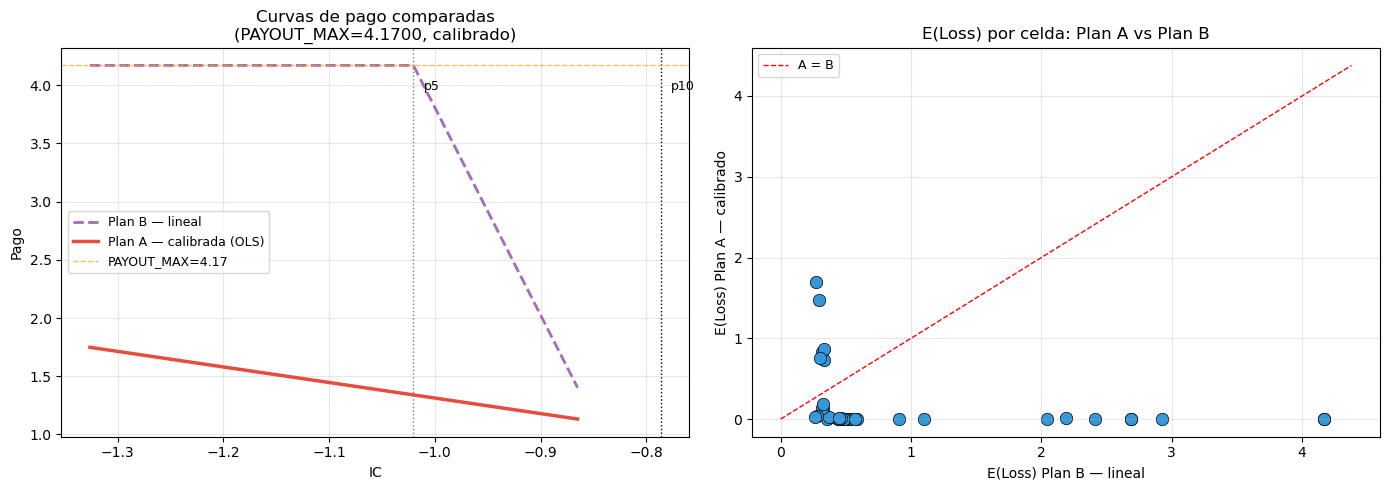


TABLA COMPARATIVA — PLAN A (OLS) vs PLAN B (LINEAL)
  PAYOUT_MAX: 4.1700 (calibrado, compartido)
  COL_PRICING: IC
  N celdas   : 36 | N sim/celda: 50,000

  Métrica                                Plan A (OLS)  Plan B (Lineal)
  ────────────────────────────────────────────────────────────────────
  R1 — Hedge Effectiveness (>=55%)            ❌ 37.5%        ❌ -788.7%
  R2 — Dispersión primas (>=20%)          ✅ 727735.2%         ✅ 804.4%
  R3 — Reproducibilidad                ❌ diff=1.3e-04   ❌ diff=9.0e-04
  E(Loss) media                              0.192769         0.990680
  Prima pura media                           0.192769         0.990680
  Prima cargada media                        0.231322         1.188817
  Corr pérdida ↔ pago                         +0.6849          +0.0915

  → Empate (1/3 vs 1/3). Desempate por HE mayor.
    PLAN A (OLS) SELECCIONADO — HE=37.5% >= -788.7%
  df_mc asignado al Plan A para exportación.


In [13]:
# =====================================================================
# 6. Comparación de planes A vs B
# =====================================================================

# ── 6a. Curvas de pago comparadas ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izq: curvas de pago
ax = axes[0]
ic_grid = np.linspace(p5_train_global * 1.3, p10_train_global * 1.1, 300)

# Plan A — curva calibrada
pago_a_grid = pago_calibrado(ic_grid)

# Plan B — curva lineal
rango_lin = p10_train_global - p5_train_global
if abs(rango_lin) < 1e-6: rango_lin = 1e-6
pago_b_grid = np.where(
    ic_grid >= p10_train_global, 0,
    np.where(ic_grid <= p5_train_global, PAYOUT_MAX,
             PAYOUT_MAX * (p10_train_global - ic_grid) / rango_lin)
)

ax.plot(ic_grid, pago_b_grid, color='#9B59B6', linewidth=2,
        linestyle='--', label=f'Plan B — lineal', alpha=0.9)
ax.plot(ic_grid, pago_a_grid, color='#E74C3C', linewidth=2.5,
        label=f'Plan A — calibrada (OLS)')
ax.axvline(p10_train_global, color='black', linestyle=':', linewidth=1)
ax.axvline(p5_train_global,  color='gray',  linestyle=':', linewidth=1)
ax.text(p10_train_global + 0.01, PAYOUT_MAX*0.95, 'p10', fontsize=9)
ax.text(p5_train_global  + 0.01, PAYOUT_MAX*0.95, 'p5',  fontsize=9)
ax.axhline(PAYOUT_MAX, color='orange', linestyle='--', linewidth=1,
           alpha=0.7, label=f'PAYOUT_MAX={PAYOUT_MAX:.2f}')
ax.set_xlabel('IC')
ax.set_ylabel('Pago')
ax.set_title(f'Curvas de pago comparadas\n(PAYOUT_MAX={PAYOUT_MAX:.4f}, calibrado)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Panel der: E(Loss) por celda — scatter A vs B
ax = axes[1]
merged = df_mc_a[['lat','lon','e_loss']].merge(
    df_mc_b[['lat','lon','e_loss']], on=['lat','lon'], suffixes=('_a','_b'))
ax.scatter(merged['e_loss_b'], merged['e_loss_a'],
           s=80, color='#3498DB', edgecolors='black', linewidths=0.5)
lim = max(merged[['e_loss_a','e_loss_b']].max()) * 1.05
ax.plot([0, lim], [0, lim], 'r--', linewidth=1, label='A = B')
ax.set_xlabel('E(Loss) Plan B — lineal')
ax.set_ylabel('E(Loss) Plan A — calibrado')
ax.set_title('E(Loss) por celda: Plan A vs Plan B')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── 6b. Tabla comparativa R1/R2/R3 ────────────────────────────────────
print('\n' + '='*65)
print('TABLA COMPARATIVA — PLAN A (OLS) vs PLAN B (LINEAL)')
print('='*65)
print(f'  PAYOUT_MAX: {PAYOUT_MAX:.4f} (calibrado, compartido)')
print(f'  COL_PRICING: {COL_PRICING}')
print(f'  N celdas   : {len(df_mc_a)} | N sim/celda: {N_SIM:,}')
print()
print(f'  {"Métrica":<35} {"Plan A (OLS)":>15} {"Plan B (Lineal)":>16}')
print('  ' + '─'*68)

he_a_str = f'{HE_a*100:.1f}%' if not np.isnan(HE_a) else 'N/A'
he_b_str = f'{HE_b*100:.1f}%' if not np.isnan(HE_b) else 'N/A'
r1_a_str = '✅' if r1_a else '❌'
r1_b_str = '✅' if r1_b else '❌'

metricas = [
    ('R1 — Hedge Effectiveness (>=55%)',  f'{r1_a_str} {he_a_str}', f'{r1_b_str} {he_b_str}'),
    ('R2 — Dispersión primas (>=20%)',    f'{"✅" if r2_a else "❌"} {dif_r2_a:.1f}%',
                                           f'{"✅" if r2_b else "❌"} {dif_r2_b:.1f}%'),
    ('R3 — Reproducibilidad',             f'{"✅" if r3_a else "❌"} diff={diff_a:.1e}',
                                           f'{"✅" if r3_b else "❌"} diff={diff_b:.1e}'),
    ('E(Loss) media',                     f'{df_mc_a.e_loss.mean():.6f}',
                                           f'{df_mc_b.e_loss.mean():.6f}'),
    ('Prima pura media',                  f'{df_mc_a.prima_pura.mean():.6f}',
                                           f'{df_mc_b.prima_pura.mean():.6f}'),
    ('Prima cargada media',               f'{df_mc_a.prima_cargada.mean():.6f}',
                                           f'{df_mc_b.prima_cargada.mean():.6f}'),
    ('Corr pérdida ↔ pago',              f'{corr_a:+.4f}', f'{corr_b:+.4f}'),
]
for nombre, val_a, val_b in metricas:
    print(f'  {nombre:<35} {val_a:>15} {val_b:>16}')

print()
# Recomendación automática
req_a = sum([r1_a, r2_a, r3_a])
req_b = sum([r1_b, r2_b, r3_b])
if req_a > req_b:
    print(f'  → Plan A cumple más requerimientos ({req_a}/3 vs {req_b}/3)')
    print(f'    PLAN A (OLS) SELECCIONADO como plan de pricing definitivo.')
    PLAN_SELECCIONADO = 'A'
    df_mc = df_mc_a.copy()
    HE = HE_a; dif_r2 = dif_r2_a; diff = diff_a
elif req_b > req_a:
    print(f'  → Plan B cumple más requerimientos ({req_b}/3 vs {req_a}/3)')
    print(f'    PLAN B (LINEAL) SELECCIONADO como plan de pricing definitivo.')
    PLAN_SELECCIONADO = 'B'
    df_mc = df_mc_b.copy()
    HE = HE_b; dif_r2 = dif_r2_b; diff = diff_b
else:
    print(f'  → Empate ({req_a}/3 vs {req_b}/3). Desempate por HE mayor.')
    if (HE_a or -999) >= (HE_b or -999):
        print(f'    PLAN A (OLS) SELECCIONADO — HE={he_a_str} >= {he_b_str}')
        PLAN_SELECCIONADO = 'A'
        df_mc = df_mc_a.copy()
        HE = HE_a; dif_r2 = dif_r2_a; diff = diff_a
    else:
        print(f'    PLAN B (LINEAL) SELECCIONADO — HE={he_b_str} > {he_a_str}')
        PLAN_SELECCIONADO = 'B'
        df_mc = df_mc_b.copy()
        HE = HE_b; dif_r2 = dif_r2_b; diff = diff_b
print(f'  df_mc asignado al Plan {PLAN_SELECCIONADO} para exportación.')


## 7. Diagnósticos HE

Análisis estratificado del Hedge Effectiveness para entender el origen del basis risk: por mes, por píxel, false positives y scatter pago-pérdida.

Los diagnósticos se ejecutan sobre el **plan seleccionado** en la sección 6.

In [22]:
# Setup diagnósticos — usar df_he del plan seleccionado
# df_he_a y df_he_b tienen: lat, lon, fecha, COL_PRICING,
#   NDVI_anom, pago, perdida (con la curva correcta de cada plan).
# Aquí añadimos p10_col, p5_col y trigger para las celdas de diagnóstico.

if PLAN_SELECCIONADO == 'A':
    df_he_diag = df_he_a.copy()
    # Plan A usa trigger global → asignarlo como columna fija
    df_he_diag['p10_col'] = p10_train_global
    df_he_diag['p5_col']  = p5_train_global
    print(f'Diagnósticos sobre Plan A (curva calibrada OLS)')
    print(f'  Trigger: global p10={p10_train_global:.4f} | p5={p5_train_global:.4f}')
else:
    df_he_diag = df_he_b.copy()
    # Plan B tiene p10_ic y p5_ic del merge con p_celda → renombrar
    df_he_diag = df_he_diag.rename(columns={
        'p10_ic': 'p10_col',
        'p5_ic' : 'p5_col'
    })
    print(f'Diagnósticos sobre Plan B (curva lineal)')
    print(f'  Trigger: p10 por celda | p5 por celda')

# Columna mes (necesaria para diagnóstico estacional)
df_he_diag['mes'] = df_he_diag['fecha'].dt.month

NOMBRE_MES = {1:'Ene',2:'Feb',3:'Mar',4:'Abr',5:'May',6:'Jun',
              7:'Jul',8:'Ago',9:'Sep',10:'Oct',11:'Nov',12:'Dic'}

# Columna trigger binario (para matriz de confusión y false positives)
df_he_diag['trigger'] = df_he_diag[COL_PRICING] < df_he_diag['p10_col']

# HE global de referencia
vp_diag  = df_he_diag['perdida'].var()
vpn_diag = (df_he_diag['perdida'] - df_he_diag['pago']).var()
HE_GLOBAL = 1 - vpn_diag / vp_diag if vp_diag > 0 else np.nan

n_pix = df_he_diag[['lat','lon']].drop_duplicates().shape[0]
print(f'\ndf_he_diag: {len(df_he_diag):,} obs | {n_pix} celdas | '
      f'HE global = {HE_GLOBAL:.4f}')
print(f'Columnas: {list(df_he_diag.columns)}')

Diagnósticos sobre Plan A (curva calibrada OLS)
  Trigger: global p10=-0.7863 | p5=-1.0203

df_he_diag: 2,097 obs | 49 celdas | HE global = 0.3750
Columnas: ['lat', 'lon', 'fecha', 'IC', 'NDVI_anom', 'pago', 'perdida', 'p10_col', 'p5_col', 'mes', 'trigger']


In [23]:
# =====================================================================
# 7.1  DIAGNÓSTICO ESTRATIFICADO DEL HE
#
# df_he_diag ya viene construido desde la celda de setup con:
#   pago, perdida, p10_col, p5_col, trigger, mes
# Solo verificamos que el HE global coincide con el reportado en 4d/5b.
# =====================================================================

vp_g  = df_he_diag['perdida'].var()
vpn_g = (df_he_diag['perdida'] - df_he_diag['pago']).var()
HE_check = 1 - vpn_g / vp_g if vp_g > 0 else np.nan

print(f'HE global (verificación)  : {HE_check:.4f}')
print(f'HE del plan {PLAN_SELECCIONADO} (sección 4d/5b): {HE:.4f}')
if abs(HE_check - HE) < 1e-4:
    print('✅ Consistente — df_he_diag usa los mismos pago/perdida que el HE reportado')
else:
    print('⚠️  Diferencia detectada — revisar construcción de df_he_diag')

print(f'\nDistribución de pago y pérdida:')
print(f'  Pago  > 0: {(df_he_diag["pago"]>0).sum():,} '
      f'({(df_he_diag["pago"]>0).mean()*100:.1f}%)')
print(f'  Pérd  > 0: {(df_he_diag["perdida"]>0).sum():,} '
      f'({(df_he_diag["perdida"]>0).mean()*100:.1f}%)')
print(f'  Ambos > 0: '
      f'{((df_he_diag["pago"]>0)&(df_he_diag["perdida"]>0)).sum():,}')


HE global (verificación)  : 0.3750
HE del plan A (sección 4d/5b): 0.3750
✅ Consistente — df_he_diag usa los mismos pago/perdida que el HE reportado

Distribución de pago y pérdida:
  Pago  > 0: 302 (14.4%)
  Pérd  > 0: 617 (29.4%)
  Ambos > 0: 263


=== HE POR MES ===
 mes mes_nombre   n     HE  pct_FP  pct_FN
   1        Ene 265  0.393     2.6    17.4
   2        Feb 143  0.528     0.0    18.9
   3        Mar 153 -0.026     2.0    12.4
   4        Abr  75  0.379     4.0    13.3
   5        May 149  0.069     4.7    18.1
   6        Jun 241  0.409     0.8    19.9
   7        Jul 255  0.588     0.8    16.1
   8        Ago 293  0.473     1.7     9.9
   9        Sep 158  0.624     1.9    19.0
  10        Oct  66  0.051     1.5    22.7
  11        Nov 166  0.128     2.4    22.9
  12        Dic 133  0.339     1.5    18.0


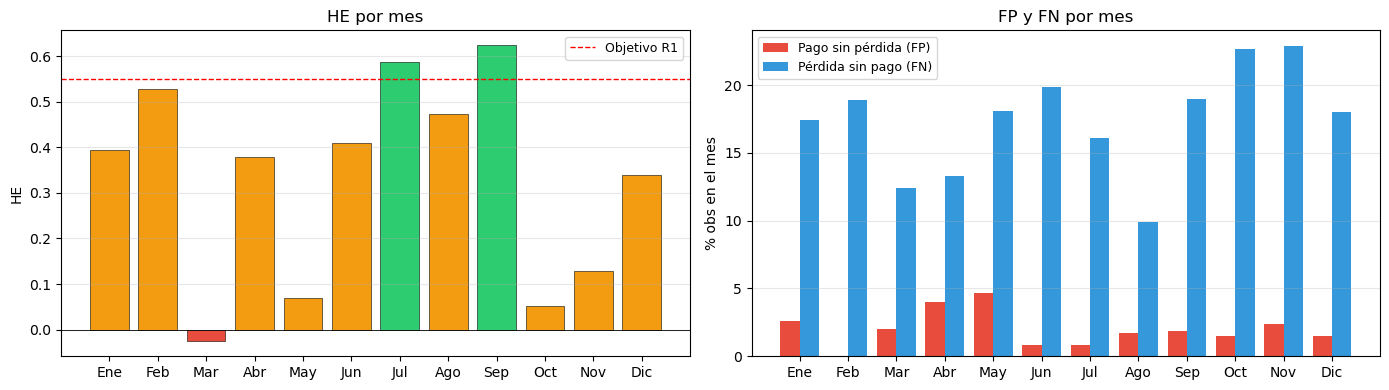

  HE Meses baja cobertura (3,4,10,11)        : +0.1023  (n=460)
  HE Meses buena cobertura                   : +0.4409  (n=1,637)


In [24]:
# 5c.1  HE por mes
#
# Si el HE negativo se concentra en marzo-abril-octubre-noviembre,
# basta un filtro estacional de payout para resolver gran parte.
# Si es uniforme, el problema está en la dependencia IC↔NDVI.
# =====================================================================

filas = []
for m in range(1, 13):
    sub = df_he_diag[df_he_diag['mes'] == m]
    if len(sub) < 30:
        filas.append({'mes': m, 'mes_nombre': NOMBRE_MES[m], 'n': len(sub),
                      'HE': np.nan, 'pct_FP': np.nan, 'pct_FN': np.nan})
        continue
    vp_m  = sub['perdida'].var()
    vpn_m = (sub['perdida'] - sub['pago']).var()
    he_m  = 1 - vpn_m/vp_m if vp_m > 0 else np.nan
    fp_m = ((sub['pago'] > 0) & (sub['perdida'] == 0)).mean() * 100
    fn_m = ((sub['perdida'] > 0) & (sub['pago'] == 0)).mean() * 100
    filas.append({
        'mes': m, 'mes_nombre': NOMBRE_MES[m], 'n': len(sub),
        'HE'    : round(he_m, 3) if not np.isnan(he_m) else np.nan,
        'pct_FP': round(fp_m, 1),    # pago > 0 sin pérdida
        'pct_FN': round(fn_m, 1),    # pérdida > 0 sin pago
    })

df_he_mes = pd.DataFrame(filas)
print('=== HE POR MES ===')
print(df_he_mes.to_string(index=False))

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
x = df_he_mes['mes'].values

ax = axes[0]
hes = df_he_mes['HE'].values
colores = ['#2ECC71' if (h is not None and not np.isnan(h) and h >= 0.55)
           else '#F39C12' if (h is not None and not np.isnan(h) and h >= 0)
           else '#E74C3C' for h in hes]
ax.bar(x, hes, color=colores, edgecolor='black', linewidth=0.4)
ax.axhline(0,    color='black', linewidth=0.6)
ax.axhline(0.55, color='red',   linestyle='--', linewidth=1, label='Objetivo R1')
ax.set_xticks(x); ax.set_xticklabels([NOMBRE_MES[m] for m in x])
ax.set_ylabel('HE'); ax.set_title('HE por mes')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='y')

ax = axes[1]
ax.bar(x - 0.2, df_he_mes['pct_FP'].values, width=0.4,
       color='#E74C3C', label='Pago sin pérdida (FP)')
ax.bar(x + 0.2, df_he_mes['pct_FN'].values, width=0.4,
       color='#3498DB', label='Pérdida sin pago (FN)')
ax.set_xticks(x); ax.set_xticklabels([NOMBRE_MES[m] for m in x])
ax.set_ylabel('% obs en el mes')
ax.set_title('FP y FN por mes')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout(); plt.show()

# Diagnóstico
meses_baja = [3, 4, 10, 11]
he_baja  = df_he_diag[df_he_diag['mes'].isin(meses_baja)]
he_alta  = df_he_diag[~df_he_diag['mes'].isin(meses_baja)]

for nombre, sub in [('Meses baja cobertura (3,4,10,11)', he_baja),
                    ('Meses buena cobertura',            he_alta)]:
    if len(sub) < 30:
        continue
    vp_s  = sub['perdida'].var()
    vpn_s = (sub['perdida'] - sub['pago']).var()
    he_s = 1 - vpn_s/vp_s if vp_s > 0 else np.nan
    print(f'  HE {nombre:<40}: {he_s:+.4f}  (n={len(sub):,})')

=== HE POR PÍXEL — distribución ===
count    39.000
mean     -0.283
std       0.849
min      -4.178
25%      -0.092
50%       0.000
75%       0.000
max       0.000

Píxeles con HE < 0  : 10 / 46 (21.7%)


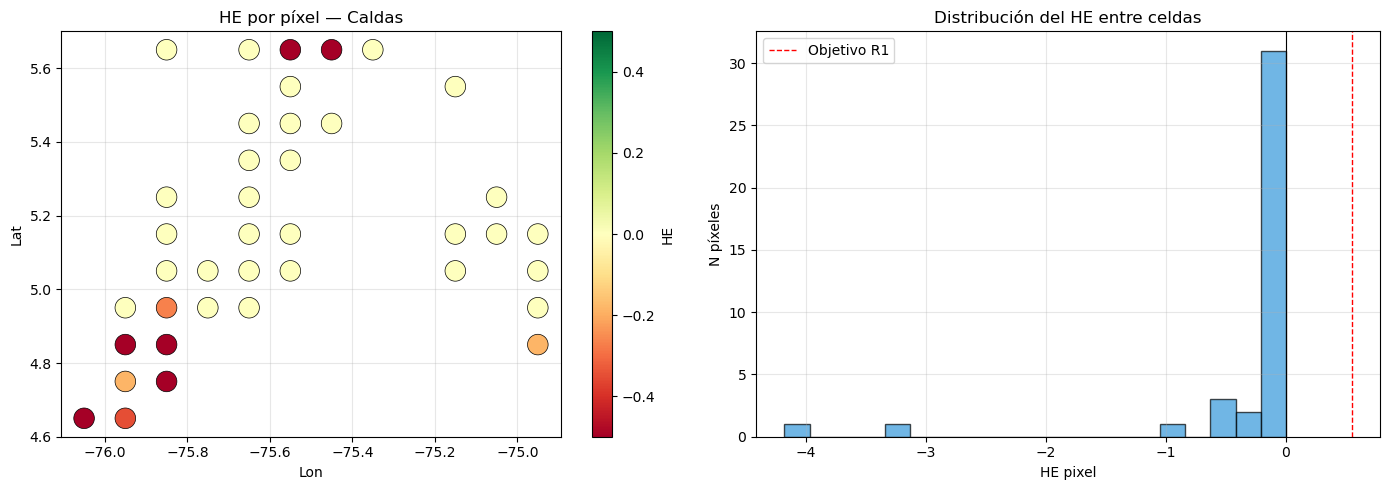


=== TOP 5 PÍXELES TÓXICOS (HE más bajo) ===
 lat      lon  n     HE  mean_pago  mean_perdida  pct_FP
5.65 -75.5503 56 -4.178     0.1099        0.0556     7.1
4.75 -75.8503 43 -3.331     1.1331        0.1740    32.6
4.85 -75.8503 53 -0.863     0.9951        0.6266     7.5
5.65 -75.4503 51 -0.594     0.0680        0.1236     2.0
4.85 -75.9503 66 -0.575     1.0179        0.5844     7.6

=== HE GLOBAL si excluimos los K píxeles peores ===
  Excluyendo  0 peores píxeles: HE = +0.3750 (n=2,097)
  Excluyendo  3 peores píxeles: HE = +0.5056 (n=1,945)
  Excluyendo  5 peores píxeles: HE = +0.5654 (n=1,828)
  Excluyendo 10 peores píxeles: HE = -0.2473 (n=1,578)
  Excluyendo 20 peores píxeles: HE = -0.3713 (n=1,143)


In [25]:
# =====================================================================
# 5c.2  HE por píxel
#
# Identifica píxeles tóxicos. En topografía heterogénea, una celda 11km
# puede contener valles + laderas con microclimas distintos. Si la
# celda promedio ERA5 no representa el clima del píxel MODIS, la
# dependencia IC↔NDVI rompe en ese píxel específico.
# =====================================================================

filas = []
for (lat, lon), sub in df_he_diag.groupby(['lat', 'lon']):
    if len(sub) < 30:
        continue
    vp_p  = sub['perdida'].var()
    vpn_p = (sub['perdida'] - sub['pago']).var()
    he_p  = 1 - vpn_p/vp_p if vp_p > 0 else np.nan
    filas.append({
        'lat': lat, 'lon': lon, 'n': len(sub),
        'HE'           : round(he_p, 3) if not np.isnan(he_p) else np.nan,
        'mean_pago'    : round(sub['pago'].mean(),    4),
        'mean_perdida' : round(sub['perdida'].mean(), 4),
        'pct_FP'       : round(((sub['pago']>0) & (sub['perdida']==0)).mean()*100, 1),
    })

df_he_pixel = pd.DataFrame(filas)
print(f'=== HE POR PÍXEL — distribución ===')
print(df_he_pixel['HE'].describe().round(3).to_string())

n_neg = (df_he_pixel['HE'] < 0).sum()
print(f'\nPíxeles con HE < 0  : {n_neg} / {len(df_he_pixel)}'
      f' ({n_neg/len(df_he_pixel)*100:.1f}%)')

# Visualizaciones
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
sc = ax.scatter(df_he_pixel['lon'], df_he_pixel['lat'],
                c=df_he_pixel['HE'], cmap='RdYlGn',
                vmin=-0.5, vmax=0.5,
                s=220, edgecolors='black', linewidths=0.5)
plt.colorbar(sc, ax=ax, label='HE')
ax.set_xlabel('Lon'); ax.set_ylabel('Lat')
ax.set_title('HE por píxel — Caldas')
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.hist(df_he_pixel['HE'].dropna(), bins=20,
        color='#3498DB', edgecolor='black', alpha=0.7)
ax.axvline(0,    color='black', linewidth=0.8)
ax.axvline(0.55, color='red', linestyle='--', linewidth=1, label='Objetivo R1')
ax.set_xlabel('HE pixel'); ax.set_ylabel('N píxeles')
ax.set_title('Distribución del HE entre celdas')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# Top píxeles tóxicos
print('\n=== TOP 5 PÍXELES TÓXICOS (HE más bajo) ===')
print(df_he_pixel.nsmallest(5, 'HE').to_string(index=False))

# Sensibilidad: HE global excluyendo los K peores
print('\n=== HE GLOBAL si excluimos los K píxeles peores ===')
df_he_pixel_sorted = df_he_pixel.sort_values('HE')
for k in [0, 3, 5, 10, 20]:
    if k >= len(df_he_pixel):
        break
    pix_excl = df_he_pixel_sorted.head(k)[['lat', 'lon']]
    if k > 0:
        df_sub = df_he_diag.merge(pix_excl, on=['lat','lon'], how='left',
                              indicator=True
                ).query('_merge == "left_only"').drop(columns='_merge')
    else:
        df_sub = df_he_diag
    vp_s  = df_sub['perdida'].var()
    vpn_s = (df_sub['perdida'] - df_sub['pago']).var()
    he_s = 1 - vpn_s/vp_s if vp_s > 0 else np.nan
    print(f'  Excluyendo {k:>2} peores píxeles: HE = {he_s:+.4f} '
          f'(n={len(df_sub):,})')

p10 NDVI_anom (train): -1.2941

Matriz de confusión (binario, p10 ↔ p10):
  TP                       : 126
  FP (trigger sin pérdida) : 176
  FN (pérdida sin trigger) : 22
  Recall    : 85.1%
  Precisión : 41.7%


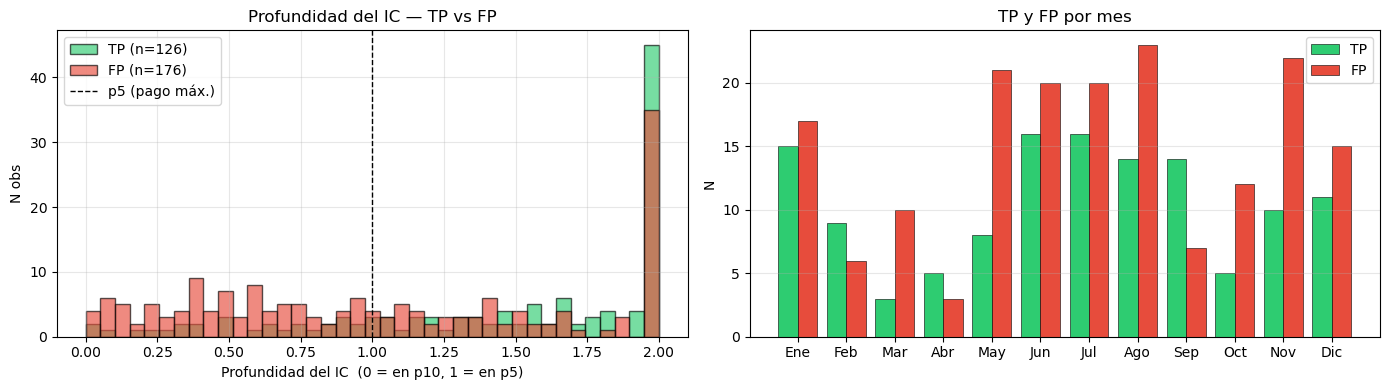


% de FP cerca del p10 (profundidad < 0.3): 13.6%
→ Los FP están profundos. El umbral no es el problema;
  la dependencia IC↔NDVI es la que está rota en esos casos.


In [26]:
# =====================================================================
# 5c.3  Distribución de false positives
#
# Cuando el IC dispara y NDVI_anom no es extremo:
#   - ¿qué tan profundo está el IC?
#     (si está cerca del p10 → endurecer trigger arregla; si está bien
#      profundo, p10 es correcto y el problema es la dependencia)
#   - ¿en qué meses ocurren?
# =====================================================================

p10_ndvi_train = df_train['NDVI_anom'].quantile(0.10)
print(f'p10 NDVI_anom (train): {p10_ndvi_train:.4f}')

df_he_diag['trigger']   = df_he_diag[COL_PRICING] < df_he_diag['p10_col']
df_he_diag['perd_extr'] = df_he_diag['NDVI_anom'] < p10_ndvi_train

n_tp = ( df_he_diag['trigger'] &  df_he_diag['perd_extr']).sum()
n_fp = ( df_he_diag['trigger'] & ~df_he_diag['perd_extr']).sum()
n_fn = (~df_he_diag['trigger'] &  df_he_diag['perd_extr']).sum()

print(f'\nMatriz de confusión (binario, p10 ↔ p10):')
print(f'  TP                       : {n_tp:,}')
print(f'  FP (trigger sin pérdida) : {n_fp:,}')
print(f'  FN (pérdida sin trigger) : {n_fn:,}')
print(f'  Recall    : {n_tp/(n_tp+n_fn)*100:.1f}%')
print(f'  Precisión : {n_tp/(n_tp+n_fp)*100:.1f}%')

# Profundidad del IC en TP y FP
df_he_diag['profundidad'] = (
    (df_he_diag['p10_col'] - df_he_diag[COL_PRICING]) /
    (df_he_diag['p10_col'] - df_he_diag['p5_col']).clip(lower=1e-6)
)
df_fp = df_he_diag[df_he_diag['trigger'] & ~df_he_diag['perd_extr']]
df_tp = df_he_diag[df_he_diag['trigger'] &  df_he_diag['perd_extr']]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
bins = np.linspace(0, 2, 40)
ax.hist(df_tp['profundidad'].clip(0, 2), bins=bins, color='#2ECC71',
        alpha=0.65, edgecolor='black', label=f'TP (n={len(df_tp)})')
ax.hist(df_fp['profundidad'].clip(0, 2), bins=bins, color='#E74C3C',
        alpha=0.65, edgecolor='black', label=f'FP (n={len(df_fp)})')
ax.axvline(1.0, color='black', linestyle='--', linewidth=1,
           label='p5 (pago máx.)')
ax.set_xlabel('Profundidad del IC  (0 = en p10, 1 = en p5)')
ax.set_ylabel('N obs')
ax.set_title('Profundidad del IC — TP vs FP')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
fp_mes = (df_fp.groupby(df_fp['fecha'].dt.month).size()
          .reindex(range(1, 13), fill_value=0))
tp_mes = (df_tp.groupby(df_tp['fecha'].dt.month).size()
          .reindex(range(1, 13), fill_value=0))
xs = fp_mes.index.values
ax.bar(xs - 0.2, tp_mes.values, width=0.4, color='#2ECC71',
       label='TP', edgecolor='black', linewidth=0.4)
ax.bar(xs + 0.2, fp_mes.values, width=0.4, color='#E74C3C',
       label='FP', edgecolor='black', linewidth=0.4)
ax.set_xticks(xs); ax.set_xticklabels([NOMBRE_MES[m] for m in xs])
ax.set_ylabel('N')
ax.set_title('TP y FP por mes')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout(); plt.show()

# Conclusiones
fp_superficiales = ((df_fp['profundidad'] < 0.3).sum() / len(df_fp) * 100
                    if len(df_fp) > 0 else 0)
print(f'\n% de FP cerca del p10 (profundidad < 0.3): {fp_superficiales:.1f}%')
if fp_superficiales > 50:
    print('→ Endurecer trigger a p5 quitaría la mayoría de los FP.')
else:
    print('→ Los FP están profundos. El umbral no es el problema;')
    print('  la dependencia IC↔NDVI es la que está rota en esos casos.')

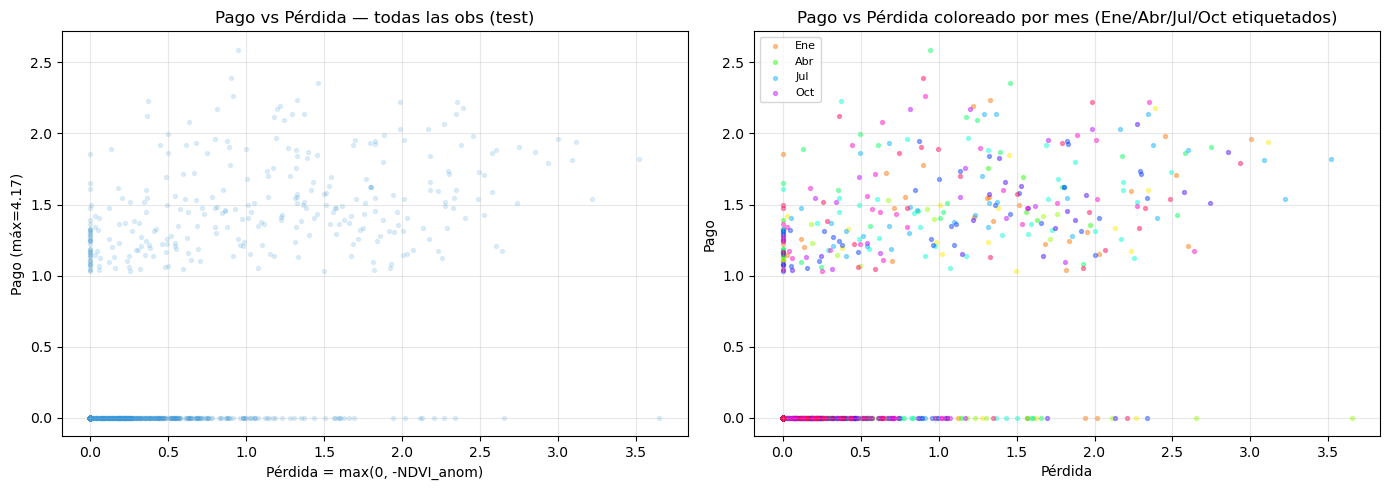

=== CUADRANTES PAGO × PÉRDIDA ===
  Pago>0  Pérdida>0  :    263  ( 12.5%)  pagos correctos
  Pago>0  Pérdida=0  :     39  (  1.9%)  FP — origen del HE bajo
  Pago=0  Pérdida>0  :    354  ( 16.9%)  FN
  Pago=0  Pérdida=0  :  1,441  ( 68.7%)  silencio correcto

=== MAGNITUDES AGREGADAS ===
  Σ Pago total        :     448.08
  Σ Pérdida total     :     489.42
  Σ Pago en FP        :      48.46  (10.8% del pago total)
  Correlación Pago↔Pérdida: +0.6849


In [27]:
# =====================================================================
# 5c.4  Scatter Pago vs Pérdida
#
# Diagnóstico visual. Patrones a buscar:
#   - Pendiente positiva clara        → buena dependencia
#   - Banda vertical en perdida=0      → false positives concentrados
#   - Banda horizontal en pago=0        → false negatives concentrados
#   - Nube sin estructura               → ruido / proxy roto
# =====================================================================

import matplotlib.cm as cm

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(df_he_diag['perdida'], df_he_diag['pago'],
           alpha=0.15, s=8, color='#3498DB')
ax.set_xlabel('Pérdida = max(0, -NDVI_anom)')
ax.set_ylabel(f'Pago (máx={PAYOUT_MAX:.2f})')
ax.set_title('Pago vs Pérdida — todas las obs (test)')
ax.grid(True, alpha=0.3)

ax = axes[1]
for m in range(1, 13):
    sub = df_he_diag[df_he_diag['mes'] == m]
    if len(sub) > 0:
        ax.scatter(sub['perdida'], sub['pago'],
                   alpha=0.4, s=8, c=[cm.hsv(m/12.5)],
                   label=NOMBRE_MES[m] if m in [1, 4, 7, 10] else None)
ax.set_xlabel('Pérdida'); ax.set_ylabel('Pago')
ax.set_title('Pago vs Pérdida coloreado por mes (Ene/Abr/Jul/Oct etiquetados)')
ax.legend(fontsize=8, loc='upper left'); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# Cuadrantes
n_total       = len(df_he_diag)
n_pago_perd   = ((df_he_diag['pago'] > 0) & (df_he_diag['perdida'] > 0)).sum()
n_pago_noperd = ((df_he_diag['pago'] > 0) & (df_he_diag['perdida'] == 0)).sum()
n_nopago_perd = ((df_he_diag['pago'] == 0) & (df_he_diag['perdida'] > 0)).sum()
n_nada        = ((df_he_diag['pago'] == 0) & (df_he_diag['perdida'] == 0)).sum()

print(f'=== CUADRANTES PAGO × PÉRDIDA ===')
print(f'  Pago>0  Pérdida>0  : {n_pago_perd:>6,}  ({n_pago_perd/n_total*100:>5.1f}%)  pagos correctos')
print(f'  Pago>0  Pérdida=0  : {n_pago_noperd:>6,}  ({n_pago_noperd/n_total*100:>5.1f}%)  FP — origen del HE bajo')
print(f'  Pago=0  Pérdida>0  : {n_nopago_perd:>6,}  ({n_nopago_perd/n_total*100:>5.1f}%)  FN')
print(f'  Pago=0  Pérdida=0  : {n_nada:>6,}  ({n_nada/n_total*100:>5.1f}%)  silencio correcto')

# Magnitud agregada
total_pago    = df_he_diag['pago'].sum()
total_perdida = df_he_diag['perdida'].sum()
pago_fp       = df_he_diag.loc[df_he_diag['perdida'] == 0, 'pago'].sum()

print(f'\n=== MAGNITUDES AGREGADAS ===')
print(f'  Σ Pago total        : {total_pago:>10.2f}')
print(f'  Σ Pérdida total     : {total_perdida:>10.2f}')
print(f'  Σ Pago en FP        : {pago_fp:>10.2f}  ({pago_fp/total_pago*100:.1f}% del pago total)')
print(f'  Correlación Pago↔Pérdida: {df_he_diag[["pago","perdida"]].corr().iloc[0,1]:+.4f}')

## 8. Exportación

Se exportan los artefactos necesarios para el API:
- `params_dist.pkl` — parámetros Weibull por celda
- `triggers.pkl` — p5 y p10 del IC por celda
- `primas_plan_a.parquet` / `primas_plan_b.parquet` — ambos planes
- `primas.parquet` — plan seleccionado (input del API)
- `config_pa3.yaml` — configuración completa
- `diagnostico_weibull.csv` — bondad de ajuste por píxel


In [ ]:
# =====================================================================
# 6. Exportar resultados para el API
#
# El API necesita:
#   - params_gamma.pkl  → parámetros Gamma por celda para E(Loss)
#   - triggers.pkl      → p5 y p10 del IC por celda
#   - primas.parquet    → tabla de primas por celda (lookup estático)
#   - config_pa3.yaml   → configuración del pricing
# =====================================================================

import joblib, yaml

# Parámetros Gamma
joblib.dump(params_dist, f'{OUTPUT_DIR}/params_dist.pkl')
# params_dist: Weibull para todos los píxeles {(lat,lon): {'dist':'weibull','params':(c,loc,scale)}}

# Triggers por celda
triggers = {
    (lat, lon): {
        'p5_ic' : row['p5_ic'],
        'p10_ic': row['p10_ic']
    }
    for _, row in df_mc.iterrows()
    for lat, lon in [(row['lat'], row['lon'])]
}
joblib.dump(triggers, f'{OUTPUT_DIR}/triggers.pkl')

# Tabla de primas — ambos planes + plan seleccionado
df_mc_a.to_parquet(f'{OUTPUT_DIR}/primas_plan_a.parquet', index=False)
df_mc_b.to_parquet(f'{OUTPUT_DIR}/primas_plan_b.parquet', index=False)
df_mc.to_parquet(f'{OUTPUT_DIR}/primas.parquet', index=False)  # plan seleccionado
print(f'Exportado: Plan {PLAN_SELECCIONADO} como primas.parquet (plan seleccionado)')

# Configuración
config_pa3 = {
    'ic_definitivo'  : COL_IC,
    'col_pricing'     : COL_PRICING,
    'usar_residuo_stl': USAR_RESIDUO,
    'distribucion'    : 'weibull',
    'justificacion_dist': 'menor AD medio entre Gamma/Lognorm/Weibull; fundamento teoría valores extremos',
    'period_stl'     : PERIOD_STL,
    'umbral_T_pct'   : UMBRAL_T,
    'n_sim_mc'       : N_SIM,
    'payout_max'     : PAYOUT_MAX,
    'loading'        : LOADING,
    'trigger_pct'    : 0.10,
    'payout_max_pct' : 0.05,
    'seed'           : 42,
    'plan_seleccionado': PLAN_SELECCIONADO,
    'curva_pago': 'OLS calibrada' if PLAN_SELECCIONADO=='A' else 'lineal p10-p5',
    'payout_max': PAYOUT_MAX,
    'metricas': {
        'HE'          : round(float(HE), 4),
        'dispersion_r2': round(float(dif_r2 if PLAN_SELECCIONADO=="A" else dif_r2), 2),
        'n_celdas'    : len(df_mc)
    }
}
with open(f'{OUTPUT_DIR}/config_pa3.yaml', 'w') as f:
    yaml.dump(config_pa3, f, default_flow_style=False, allow_unicode=True)

# Diagnóstico de ajuste Gamma
df_diag.to_csv(f'{OUTPUT_DIR}/diagnostico_gamma.csv', index=False)

print('Archivos exportados en output_pa3/:')
for f in sorted(os.listdir(OUTPUT_DIR)):
    size = os.path.getsize(f'{OUTPUT_DIR}/{f}') / 1024
    print(f'  {f:<40} {size:>8.1f} KB')

print('\n✅ PA3 completa. Listo para construir el API (FastAPI).')